In [13]:
import sys, os
#os.chdir("..")
sys.path.insert(0, "./src")
#sys.path.insert(0, '/mnt/e/ws/unfold/src')

In [14]:
os.getcwd()

'/mnt/8A04C21E04C20CDF/wsLinux/unfold'

In [15]:
# ---- Import necessary libraries and set up paths ---- #
from pathlib import Path
import uuid
import subprocess
import traceback
import warnings
import webbrowser

import ipywidgets as widgets
import numpy as np
import ROOT
from IPython.display import HTML, Markdown, clear_output, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT / "unfold" / "src").exists():
    REPO_ROOT = (REPO_ROOT / "unfold").resolve()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

OUTPUTS_ROOT = REPO_ROOT / "outputs" / "mass"
GALLERY_SCRIPT = REPO_ROOT / "outputs" / "build_mass_gallery.py"
GALLERY_HTML = OUTPUTS_ROOT / "index.html"

from unfold.tools.Unfolder_mass import Unfolder
from unfold.utils.merge_helpers import *

ROOT.gErrorIgnoreLevel = ROOT.kWarning
warnings.filterwarnings("ignore", module="ROOT")
ROOT.gErrorIgnoreLevel = ROOT.kError
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
hep.style.use("CMS")

In [5]:
# ---- Running widget ---- #
MODE_CONFIGS = [
    ("ungroomed", False),
    ("groomed", True),
]


def save_mode_artifacts(mode_name, unfolder_instance):
    np.savez(REPO_ROOT / "outputs" / f"unfolding_mosaic_mass_{mode_name}.npz", mosaic=unfolder_instance.mosaic)
    np.savez(REPO_ROOT / "outputs" / f"unfolding_mosaic_2d_mass_{mode_name}.npz", mosaic_2d=unfolder_instance.mosaic_2d)


def build_mass_gallery():
    subprocess.run(
        [sys.executable, str(GALLERY_SCRIPT), "--root", str(OUTPUTS_ROOT)],
        check=True,
        cwd=str(REPO_ROOT),
    )
    return GALLERY_HTML


def run_mode(mode_name, groomed_flag, *, closure=False, herwig_closure=False, do_syst=True, show=False):
    print(f"===== Running {mode_name} =====")
    mode_unfolder = Unfolder(
        groomed=groomed_flag,
        closure=closure,
        herwig_closure=herwig_closure,
        do_syst=do_syst,
    )
    mode_unfolder.run_all_plots(show=show)
    mode_unfolder.plot_jk(show=show)
    save_mode_artifacts(mode_name, mode_unfolder)
    return mode_unfolder


def use_unfolder(mode_name="ungroomed"):
    global unfolder, groomed
    unfolder = unfolders[mode_name]
    groomed = mode_name == "groomed"
    display(Markdown(f"Using `unfolder_{mode_name}` for follow-up cells."))
    return unfolder


def run_master_mass(*, closure=False, herwig_closure=False, do_syst=True, show=False):
    global unfolders, unfolder_ungroomed, unfolder_groomed, unfolder
    global groomed, closure_state, herwig_closure_state
    unfolders = {}
    for mode_name, groomed_flag in MODE_CONFIGS:
        unfolders[mode_name] = run_mode(
            mode_name,
            groomed_flag,
            closure=closure,
            herwig_closure=herwig_closure,
            do_syst=do_syst,
            show=show,
        )
    unfolder_ungroomed = unfolders["ungroomed"]
    unfolder_groomed = unfolders["groomed"]
    unfolder = unfolder_ungroomed
    groomed = False
    closure_state = closure
    herwig_closure_state = herwig_closure
    gallery_path = build_mass_gallery()
    return gallery_path


def validate_master_run_state():
    expected_modes = {mode_name for mode_name, _ in MODE_CONFIGS}
    if not isinstance(globals().get("unfolders"), dict):
        raise RuntimeError("Master run did not create the unfolders dictionary.")
    missing_modes = sorted(expected_modes.difference(unfolders))
    if missing_modes:
        raise RuntimeError(f"Master run finished without creating: {', '.join(missing_modes)}")
    if globals().get("unfolder_ungroomed") is not unfolders.get("ungroomed"):
        raise RuntimeError("Master run did not expose unfolder_ungroomed.")
    if globals().get("unfolder_groomed") is not unfolders.get("groomed"):
        raise RuntimeError("Master run did not expose unfolder_groomed.")


def show_captured_logs(log_text, title="Captured stdout/stderr"):
    if not log_text.strip():
        display(Markdown("No logs were captured."))
        return
    import html as _html
    escaped = _html.escape(log_text)
    display(
        HTML(
            "<details open>"
            f"<summary><b>{title}</b></summary>"
            "<pre style='max-height: 480px; overflow-y: auto; white-space: pre-wrap; border: 1px solid #ddd; padding: 8px;'>"
            f"{escaped}</pre>"
            "</details>"
        )
    )


for stale_name in ["run_button", "open_button", "master_output", "master_controls", "print_logs_checkbox"]:
    stale_widget = globals().get(stale_name)
    if stale_widget is not None:
        try:
            if hasattr(stale_widget, "_click_handlers"):
                stale_widget._click_handlers.callbacks.clear()
            stale_widget.close()
        except Exception:
            pass

MASTER_UI_ID = uuid.uuid4().hex[:8]

master_output = widgets.Output()
run_button = widgets.Button(description="Run groomed + ungroomed", button_style="primary", icon="play")
open_button = widgets.Button(description="Open mass gallery", button_style="success", icon="external-link")
print_logs_checkbox = widgets.Checkbox(value=False, description="Print full logs", indent=False)
run_button._master_id = MASTER_UI_ID
open_button._master_id = MASTER_UI_ID
open_button.disabled = not GALLERY_HTML.exists()
status_html = widgets.HTML(
    value=f"<b>Master runner</b> <code>{MASTER_UI_ID}</code>: builds ungroomed and groomed outputs, refreshes the mass gallery, and leaves <code>unfolder_ungroomed</code> / <code>unfolder_groomed</code> available for extra cells."
)


def show_gallery_link(gallery_path):
    display(HTML(f'<a href="{gallery_path.resolve().as_uri()}" target="_blank">Open outputs/mass/index.html</a>'))


_master_run_active = False


def handle_run(btn):
    global _master_run_active
    if getattr(btn, "_master_id", None) != MASTER_UI_ID:
        return
    if _master_run_active:
        return
    _master_run_active = True
    run_button.disabled = True
    open_button.disabled = True
    run_log_text = ""
    with master_output:
        clear_output()
        display(Markdown("Running ungroomed + groomed master workflow..."))
        try:
            import contextlib
            import io

            if print_logs_checkbox.value:
                gallery_path = run_master_mass(show=False)
            else:
                log_buffer = io.StringIO()
                with contextlib.redirect_stdout(log_buffer), contextlib.redirect_stderr(log_buffer):
                    gallery_path = run_master_mass(show=False)
                run_log_text = log_buffer.getvalue()

            validate_master_run_state()
            display(Markdown("Finished. Default `unfolder` now points to `unfolder_ungroomed`. Use `use_unfolder(\"groomed\")` if you want the groomed object in later cells."))
            show_gallery_link(gallery_path)
            if print_logs_checkbox.value:
                display(Markdown("Full logs were streamed live to this output cell."))
            open_button.disabled = False
        except Exception:
            display(Markdown("Master run failed before creating the expected unfolding objects."))
            if not print_logs_checkbox.value:
                show_captured_logs(run_log_text, title="Captured logs before failure")
            traceback.print_exc()
        finally:
            _master_run_active = False
            run_button.disabled = False


def handle_open(btn):
    if getattr(btn, "_master_id", None) != MASTER_UI_ID:
        return
    gallery_path = GALLERY_HTML
    if not gallery_path.exists():
        gallery_path = build_mass_gallery()
    webbrowser.open(gallery_path.resolve().as_uri())
    with master_output:
        display(Markdown("Sent gallery URL to the local browser opener."))
        show_gallery_link(gallery_path)


run_button.on_click(handle_run)
open_button.on_click(handle_open)

master_controls = widgets.VBox([
    status_html,
    widgets.HBox([run_button, open_button, print_logs_checkbox]),
    master_output,
])
display(master_controls)

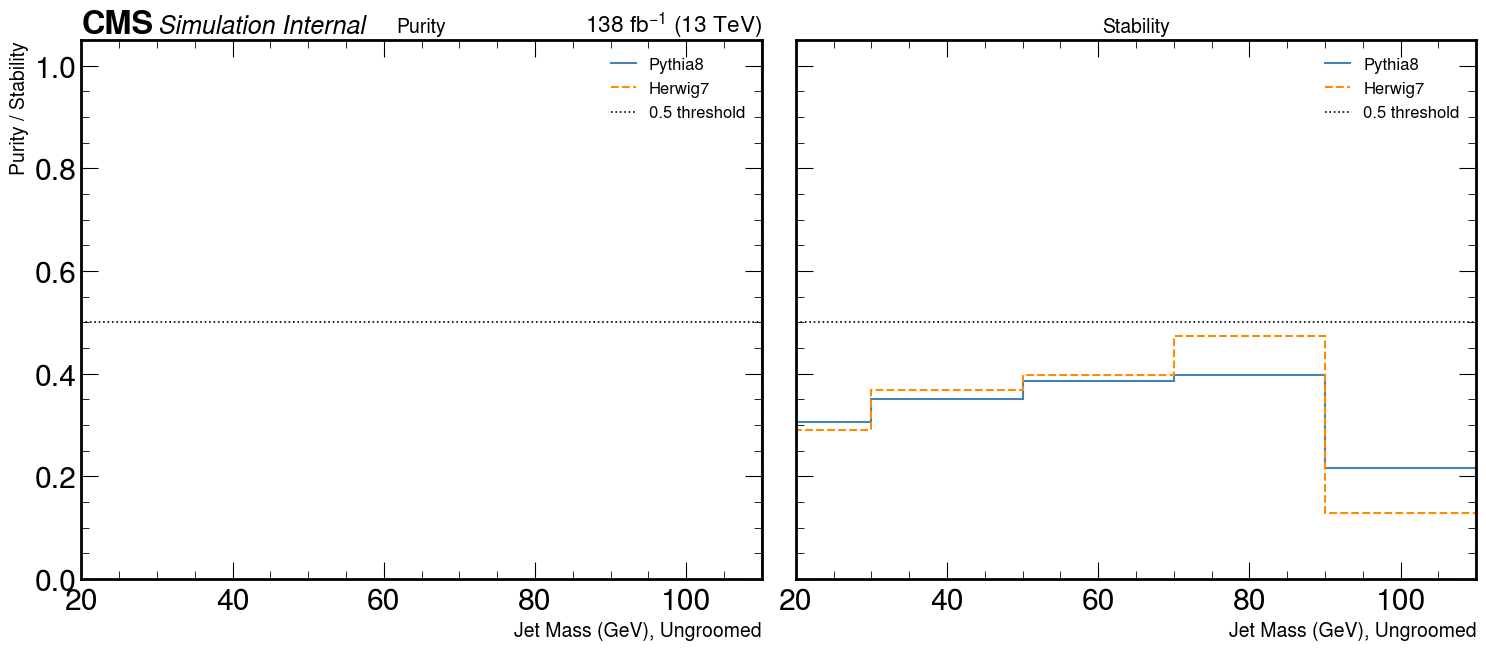

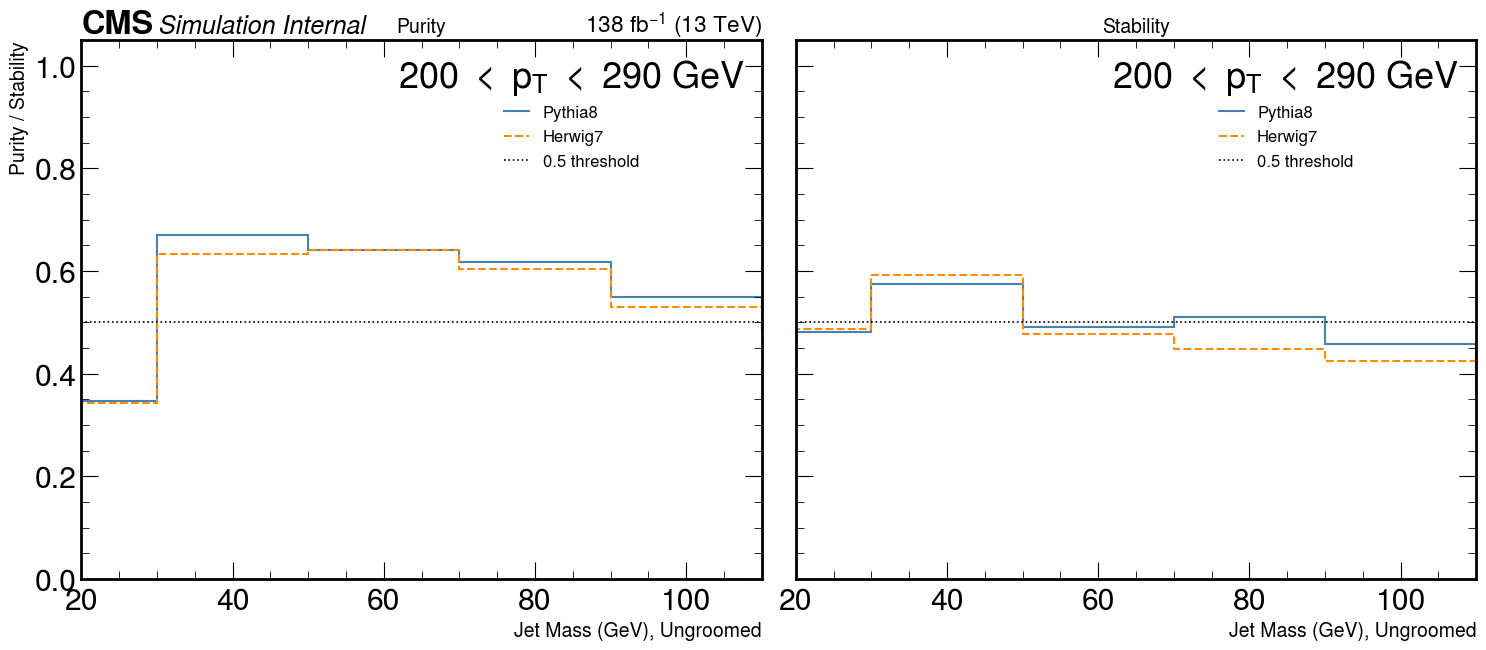

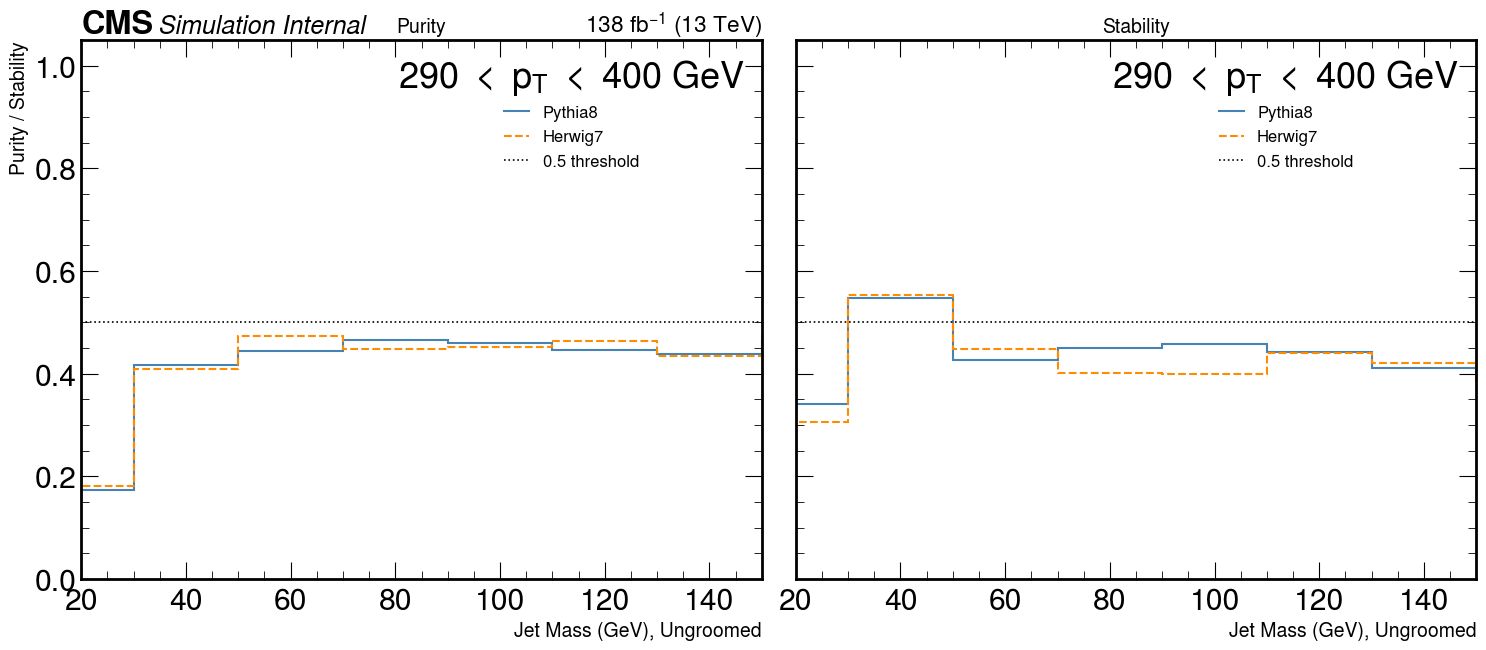

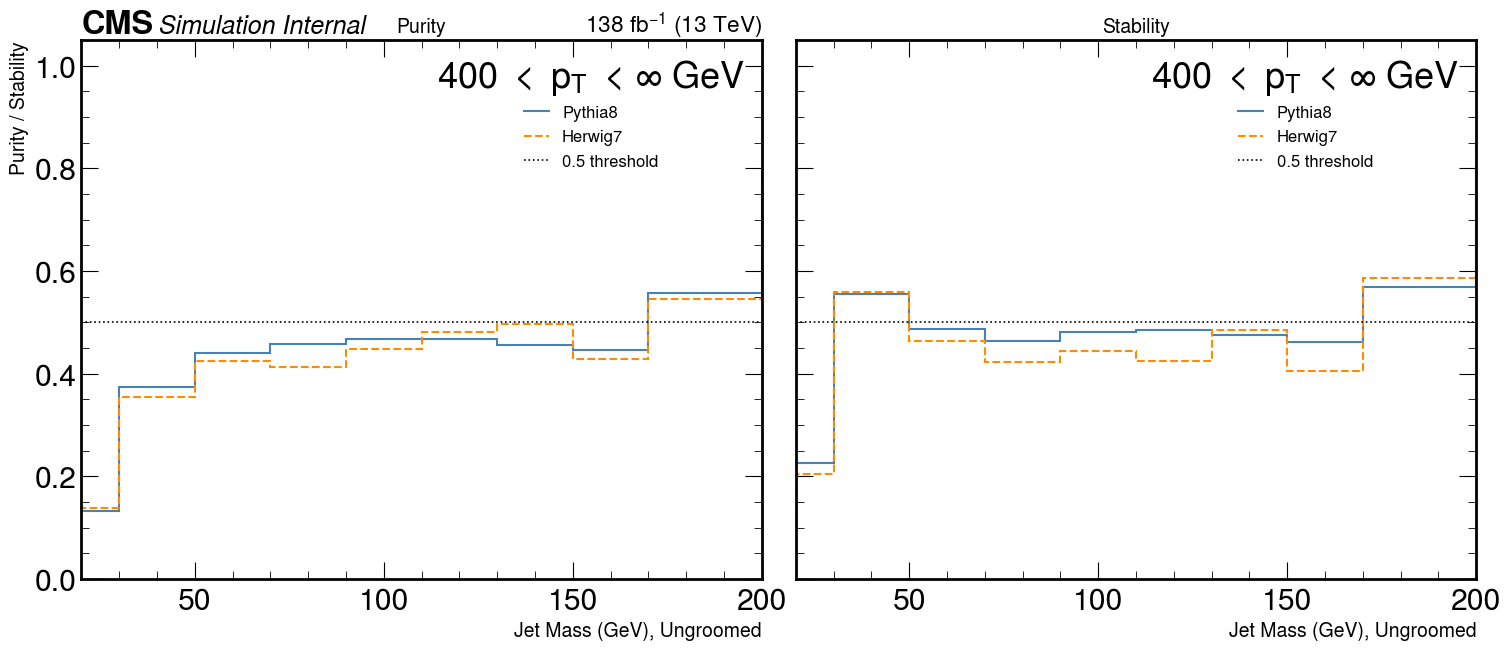

In [17]:
unfolder.plot_purity_stability_herwig()

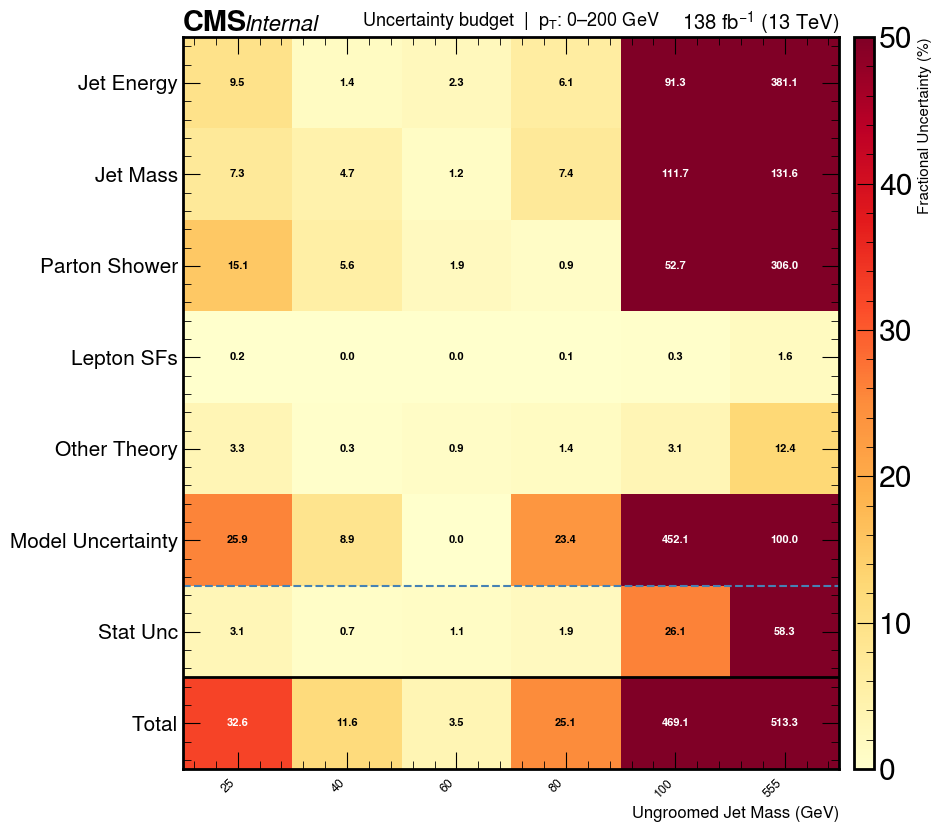

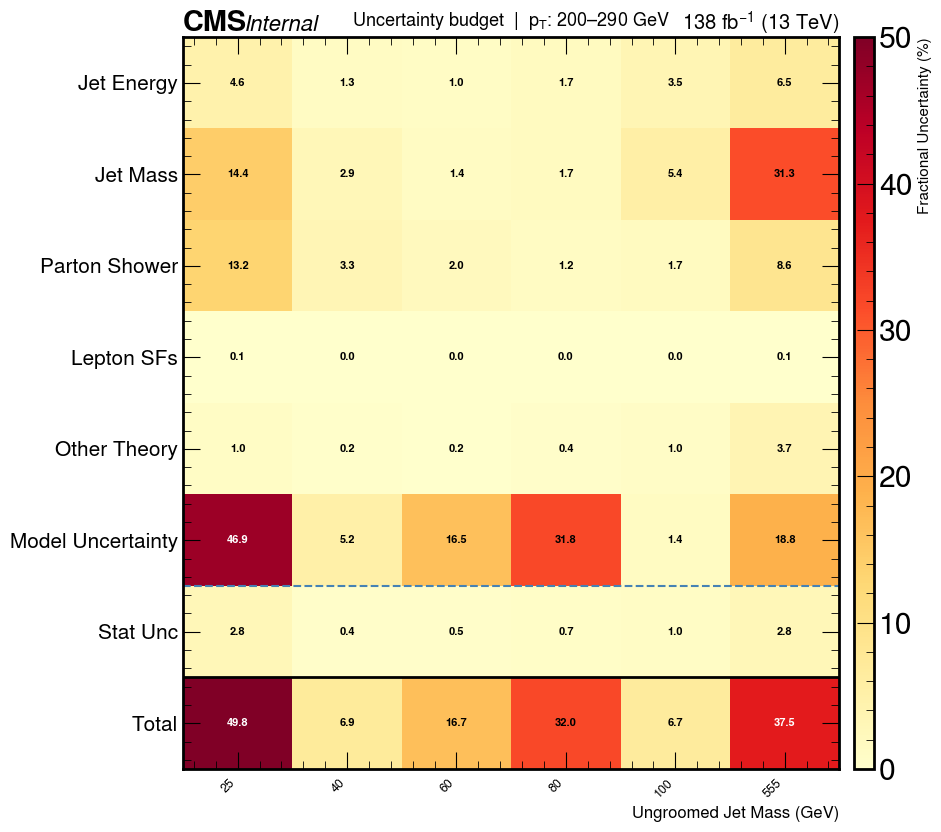

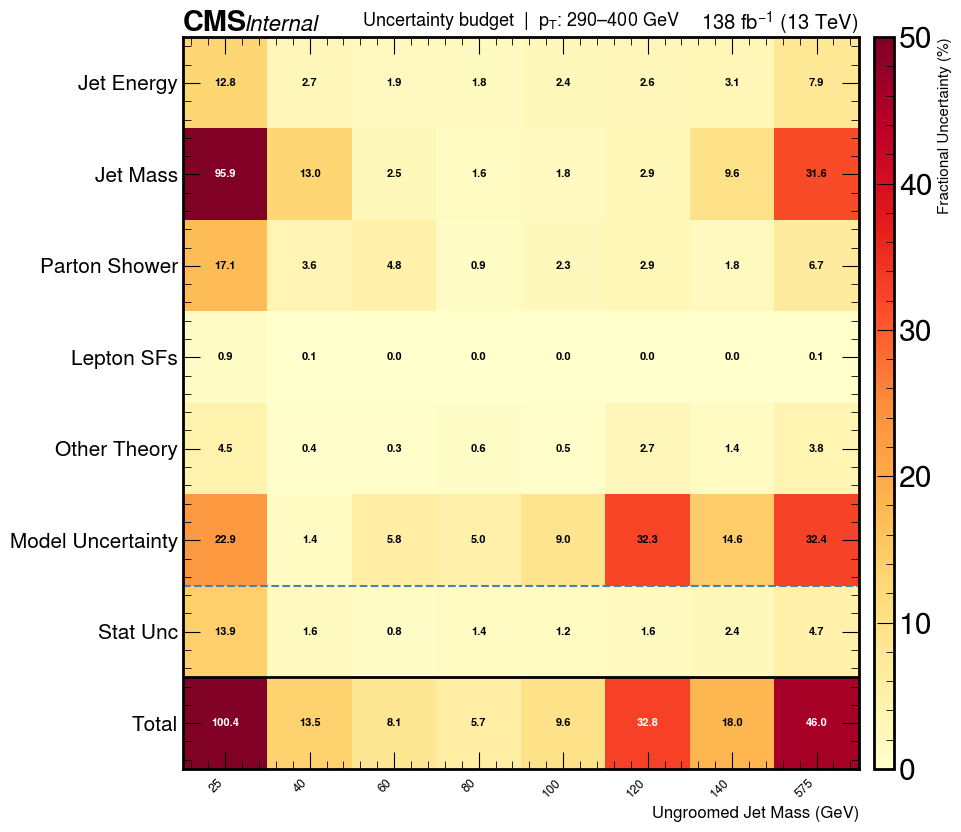

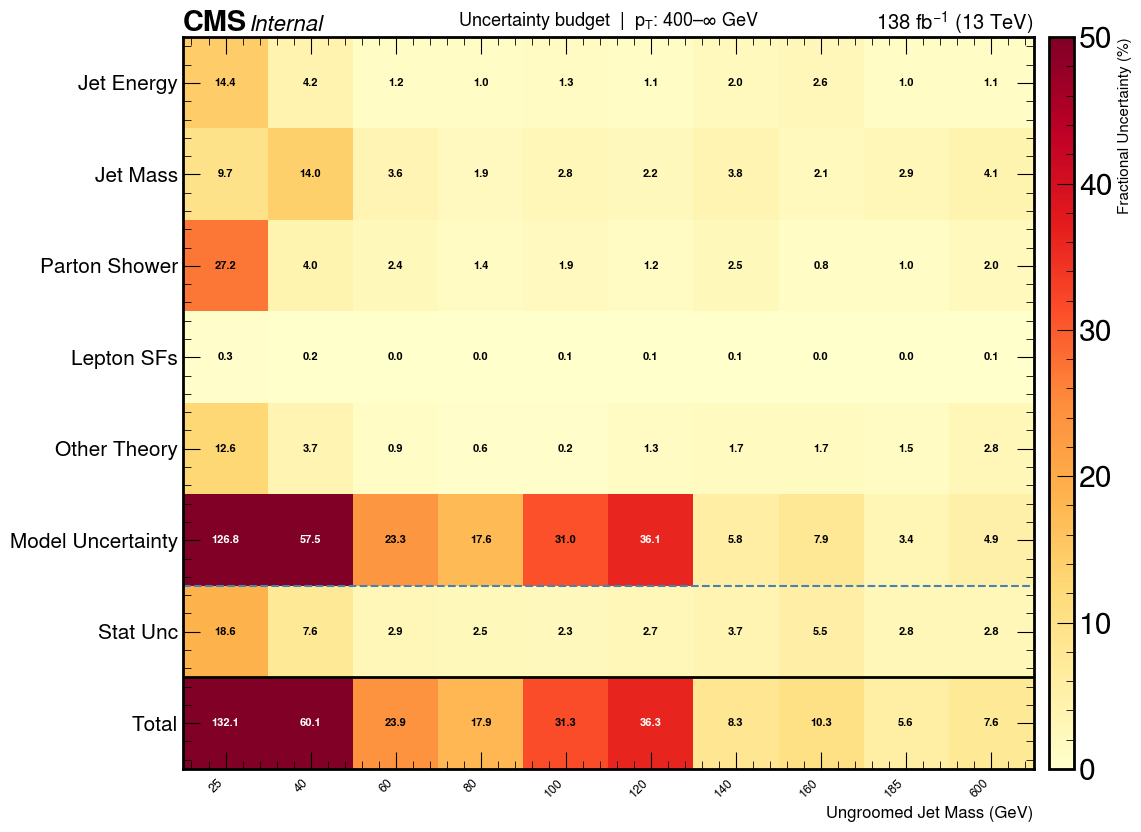

In [8]:
unfolder.plot_uncertainty_heatmap()

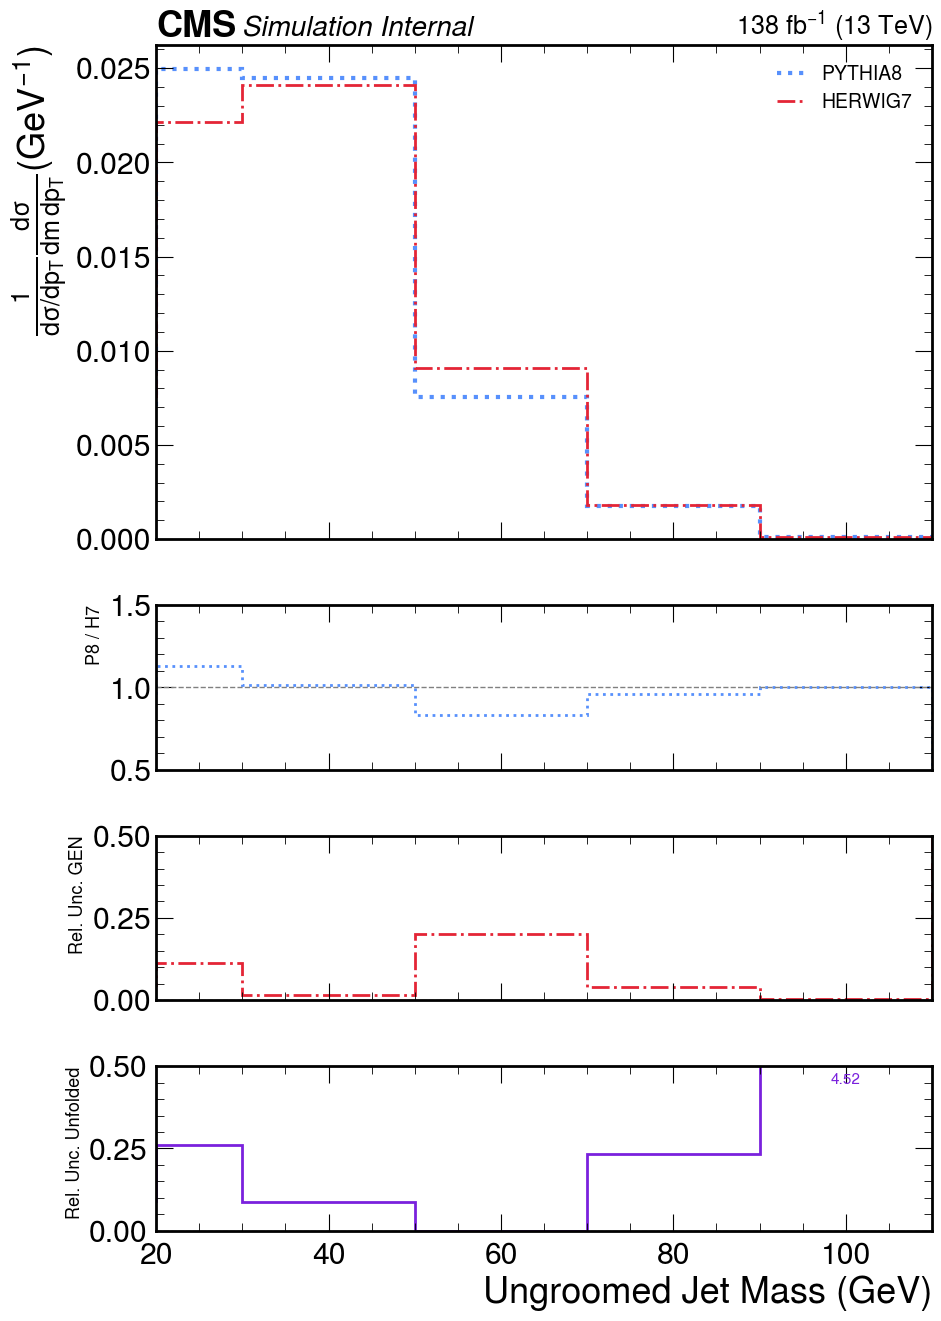

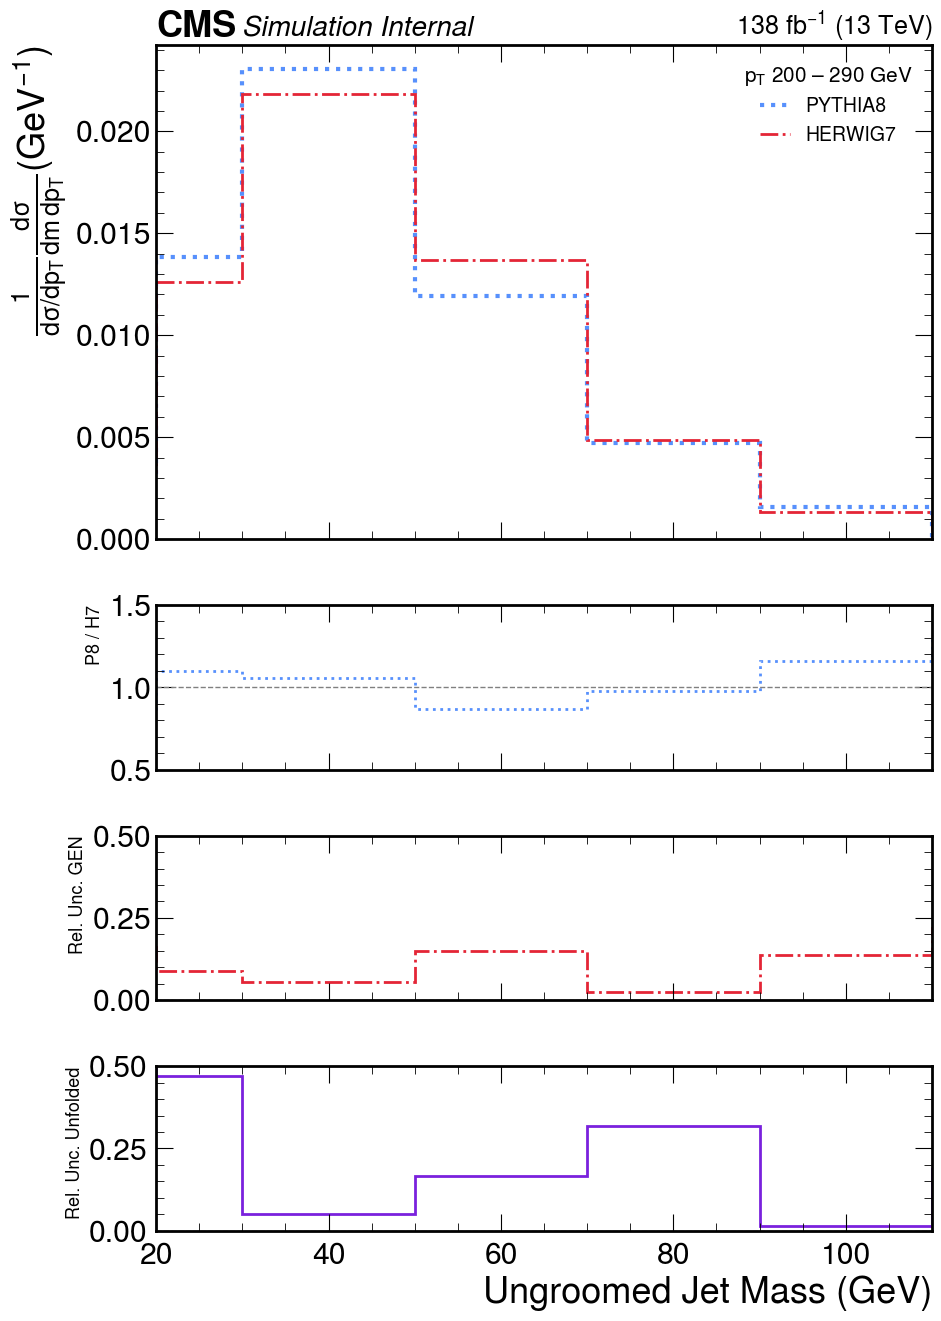

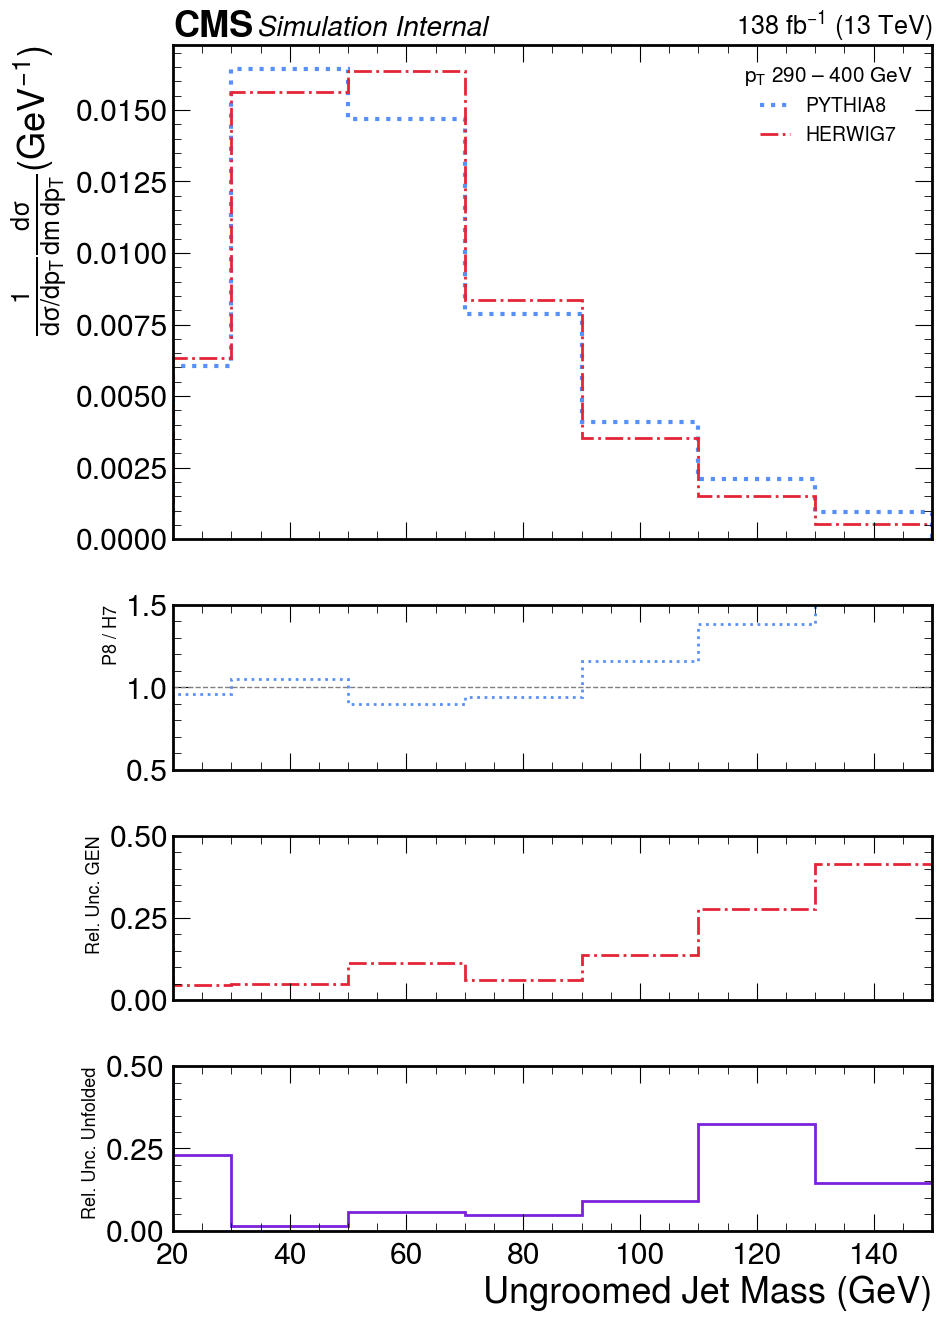

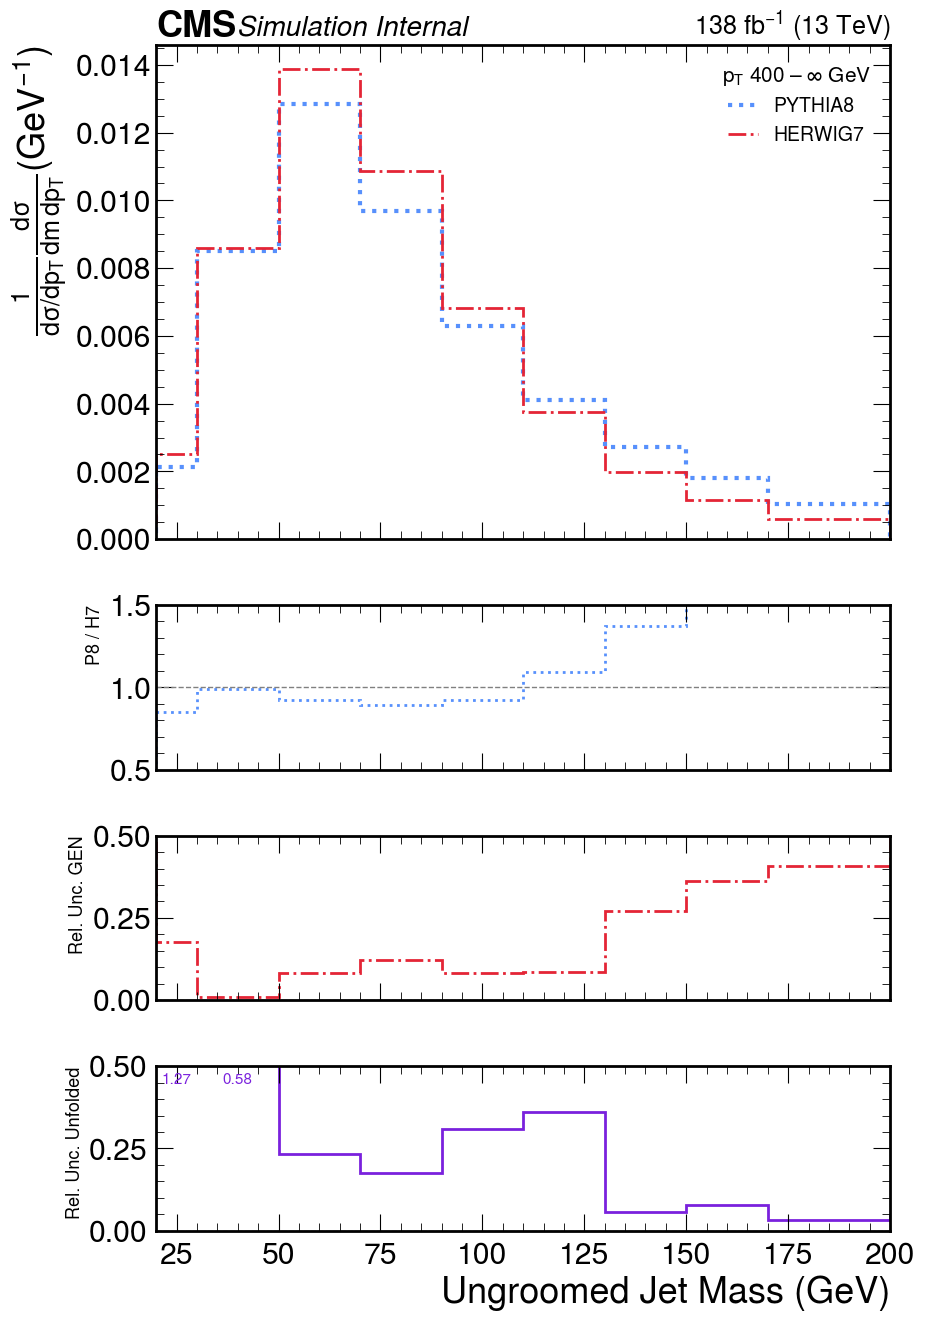

In [12]:
unfolder.plot_herwig_pythia_comparison()

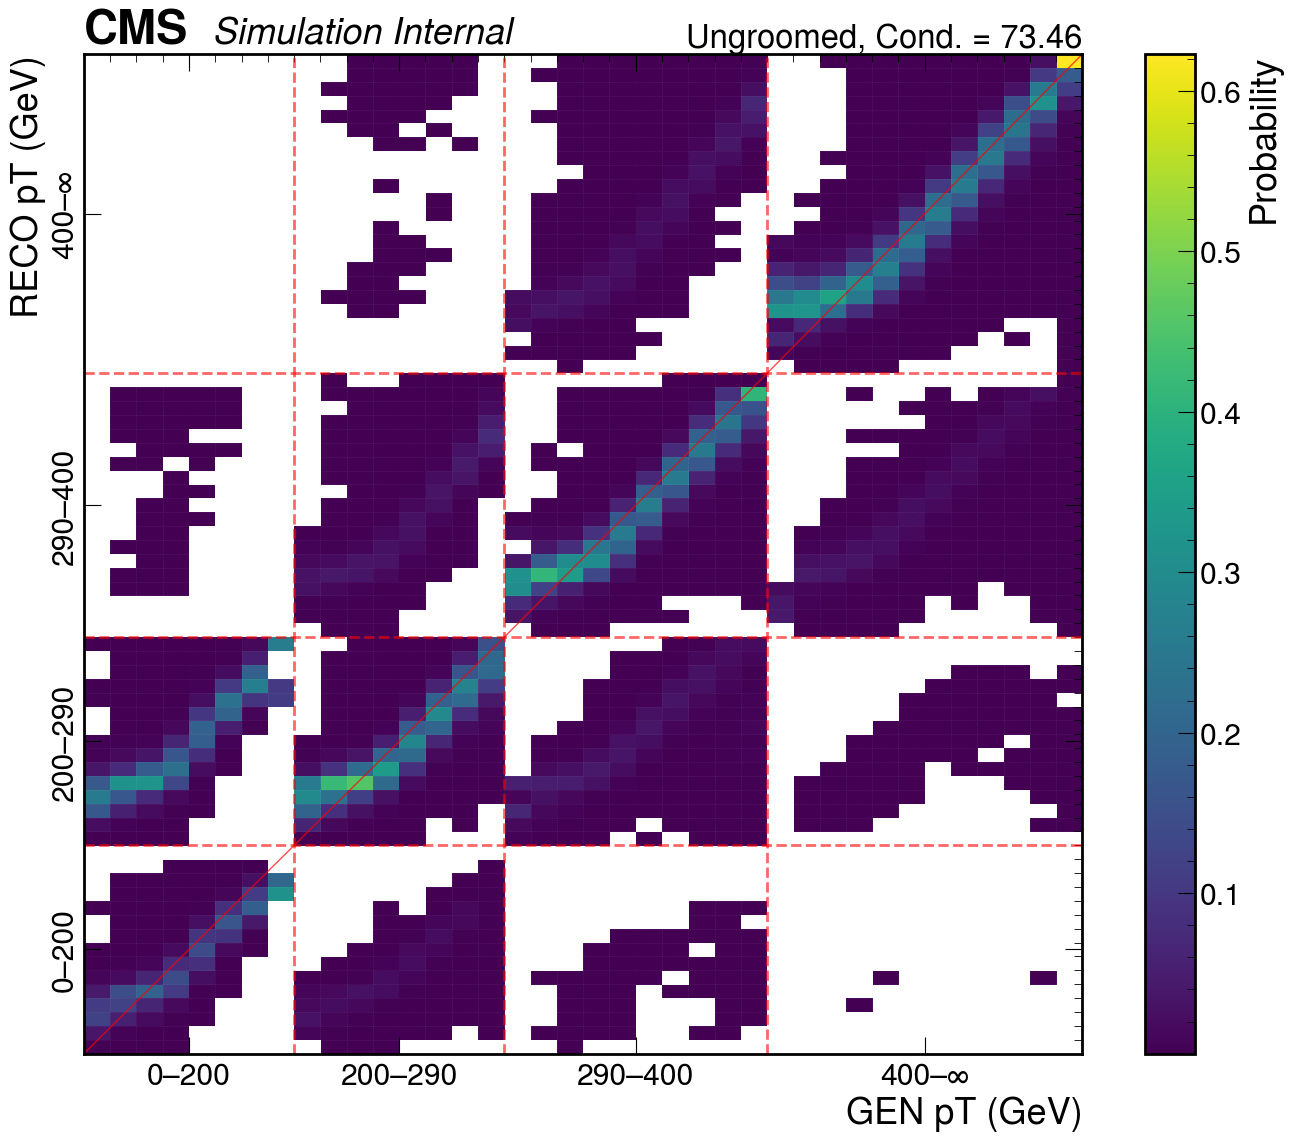

In [16]:
unfolder_ungroomed.plot_response_matrix()

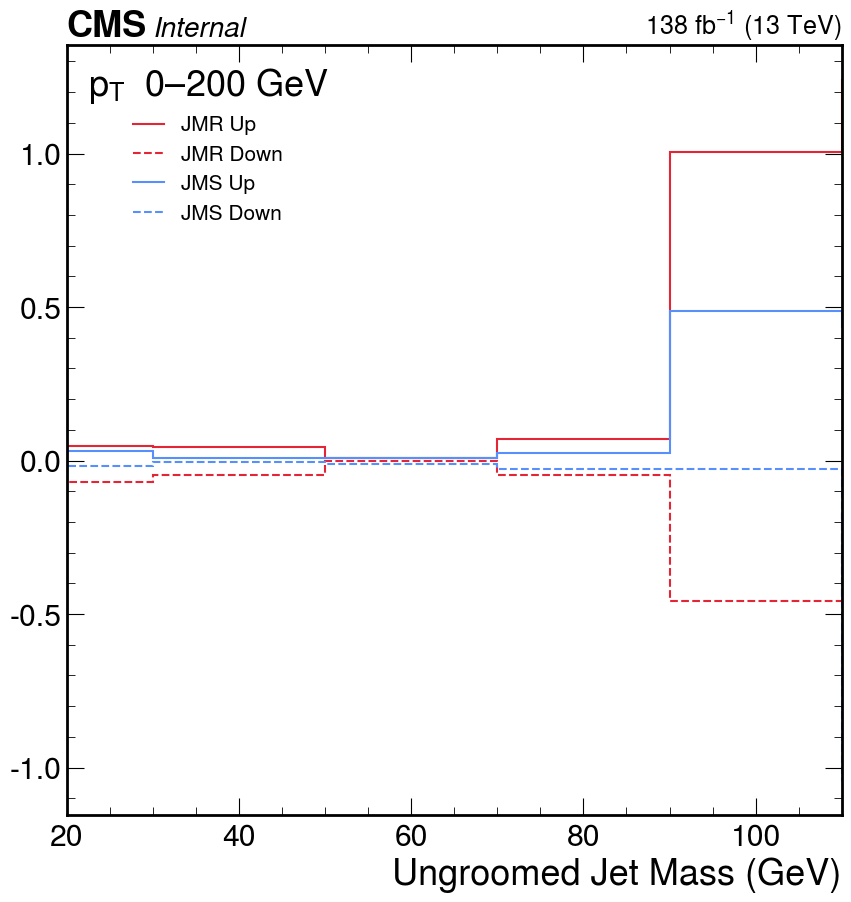

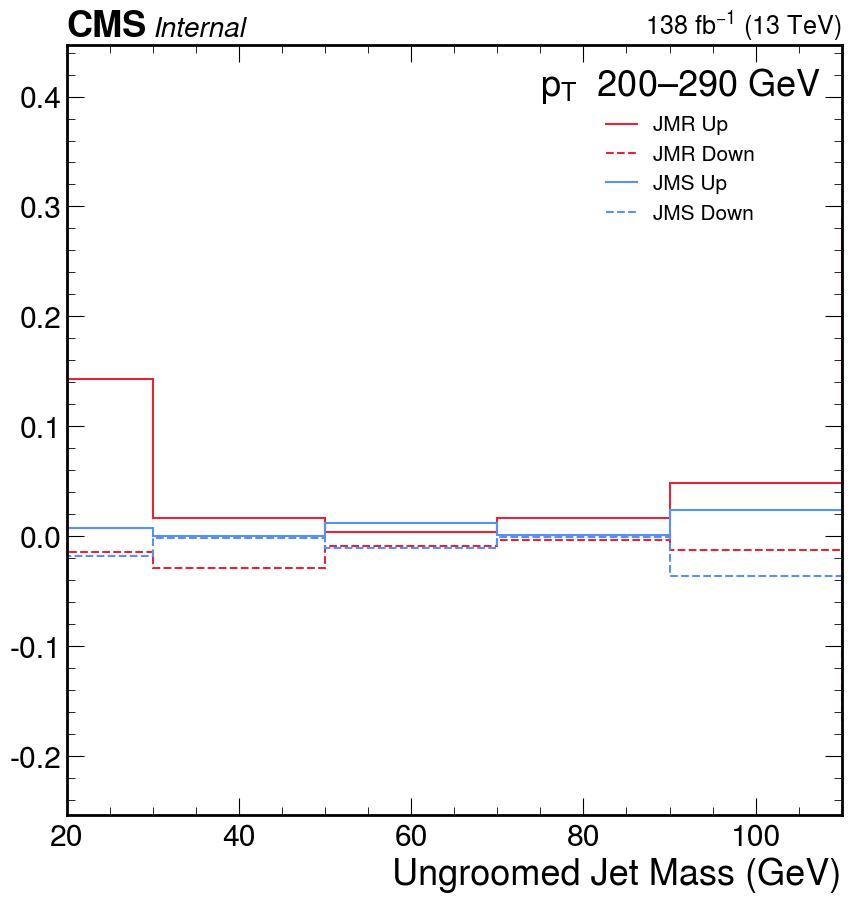

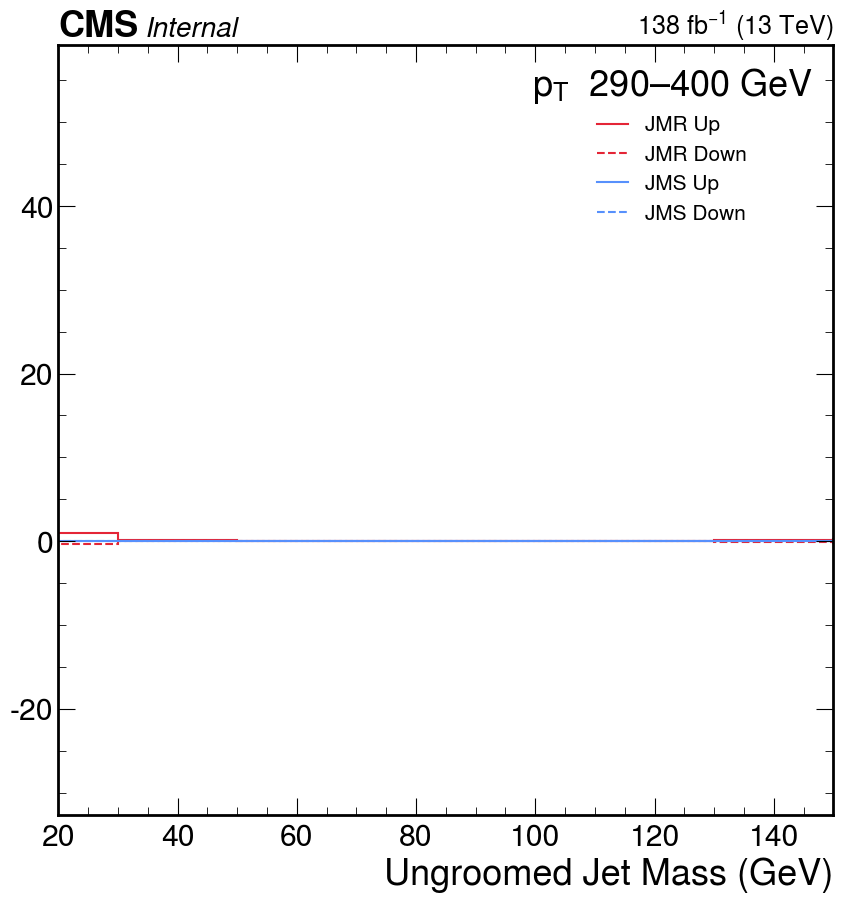

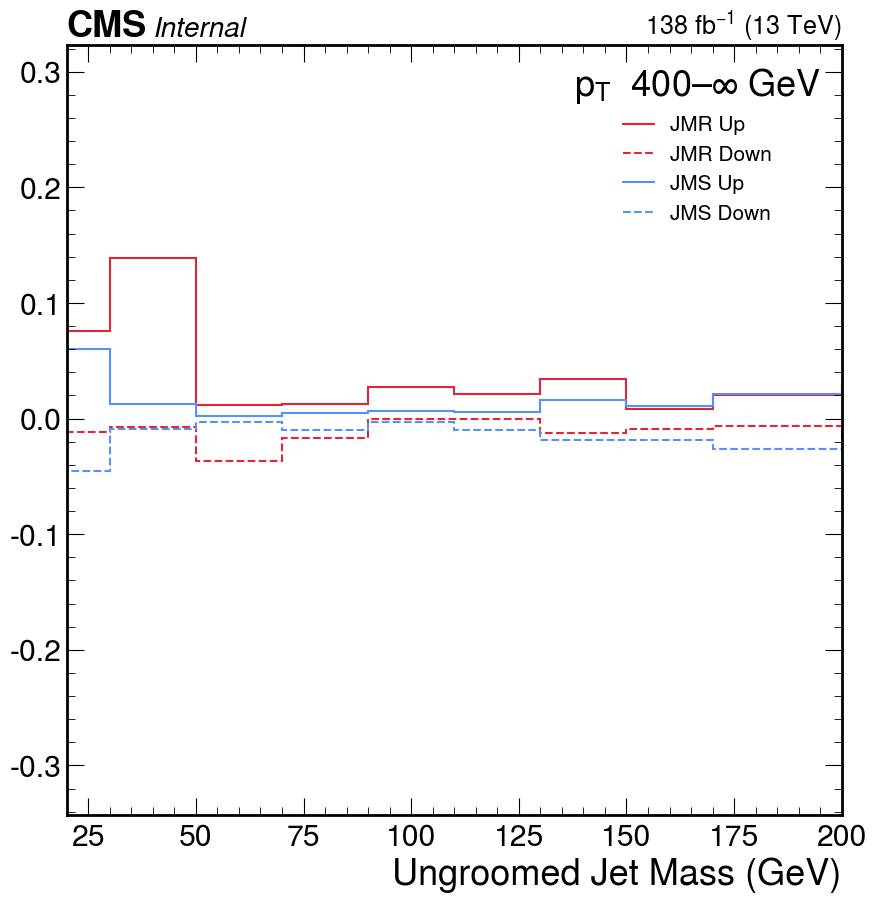

In [17]:
unfolder_ungroomed.plot_systematic_frac_indiv(["JMR", "JMS"])

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/tools/Unfolder_mass.py:850: RuntimeWarning: divide by zero encountered in divide
  ratio_herwig = np.divide(unfolded, herwig_norm)


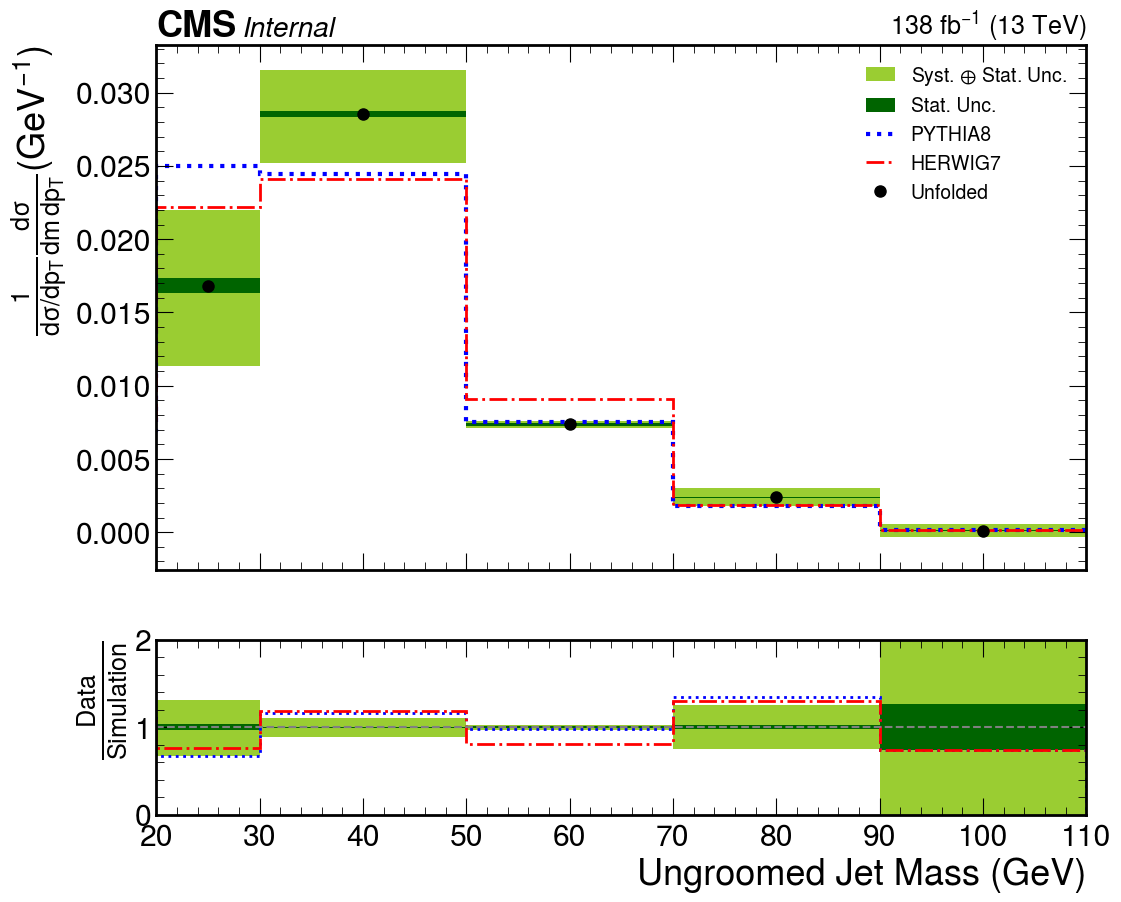

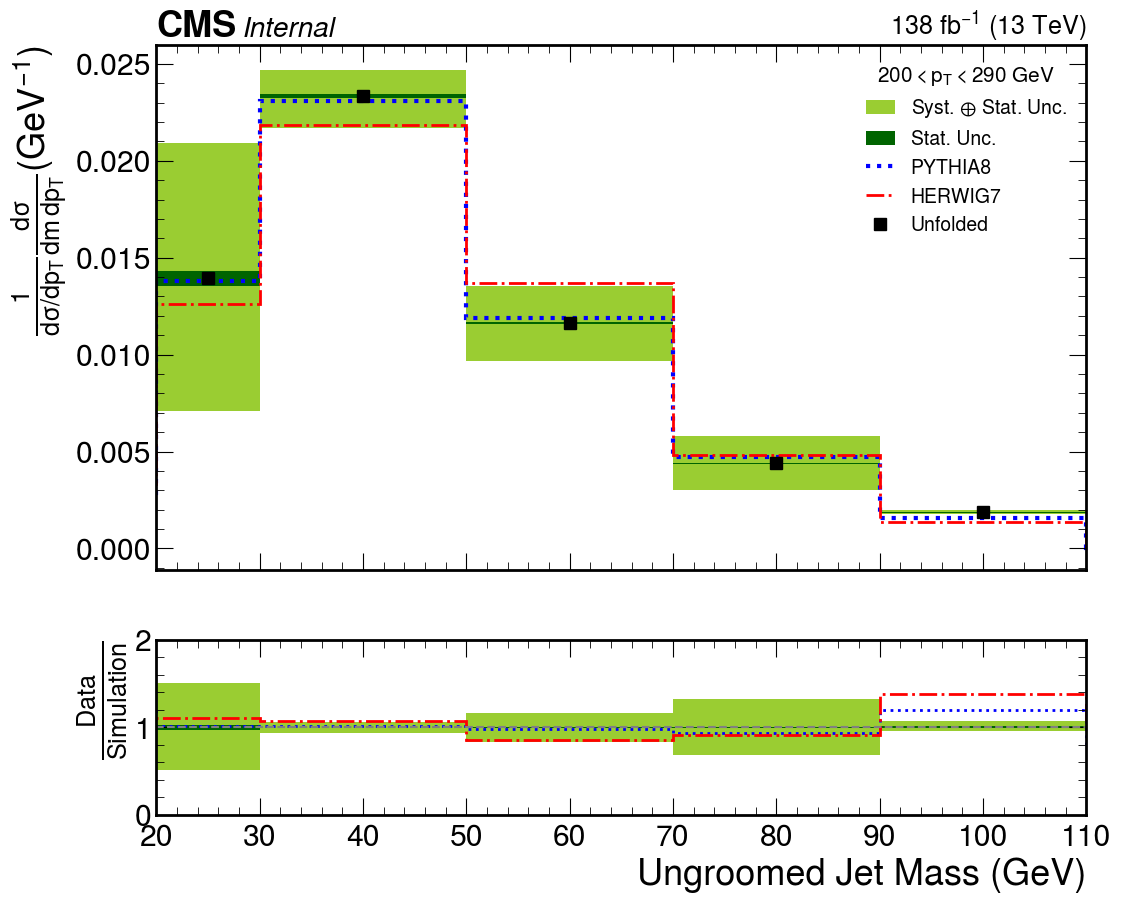

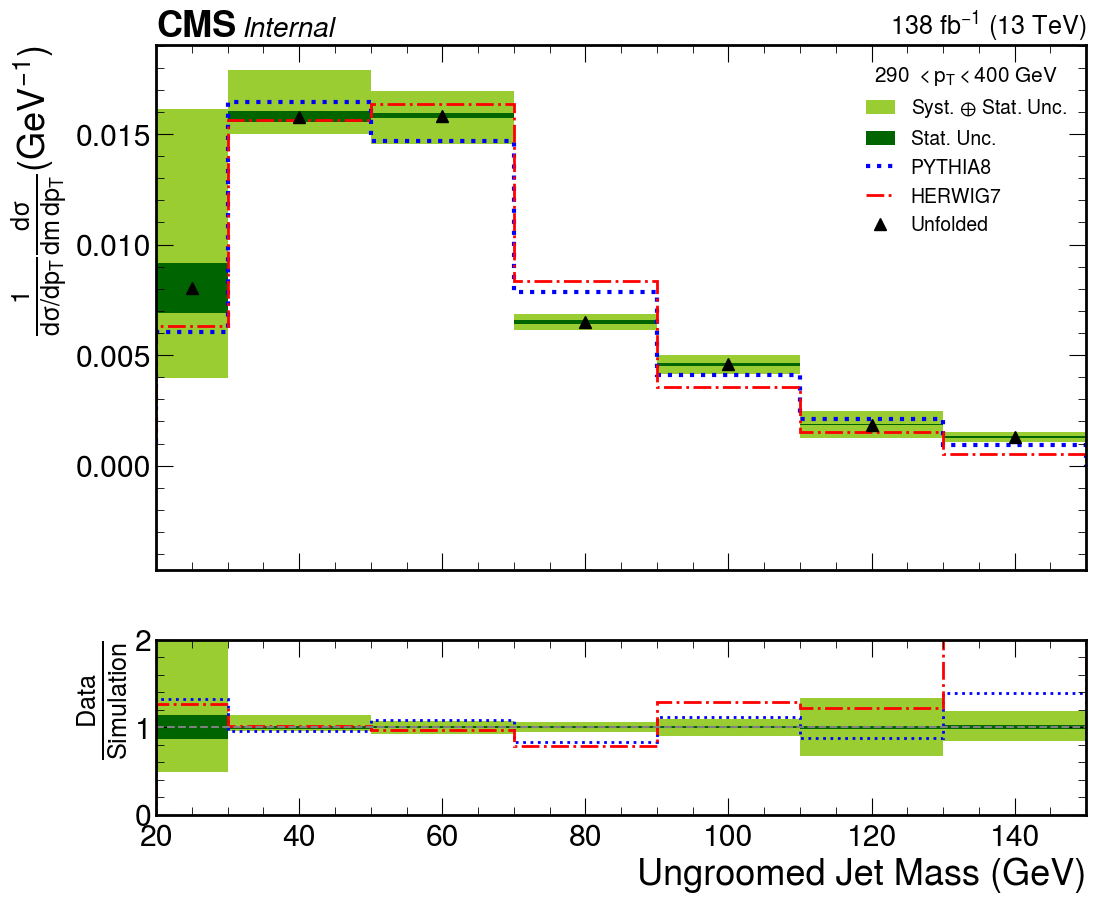

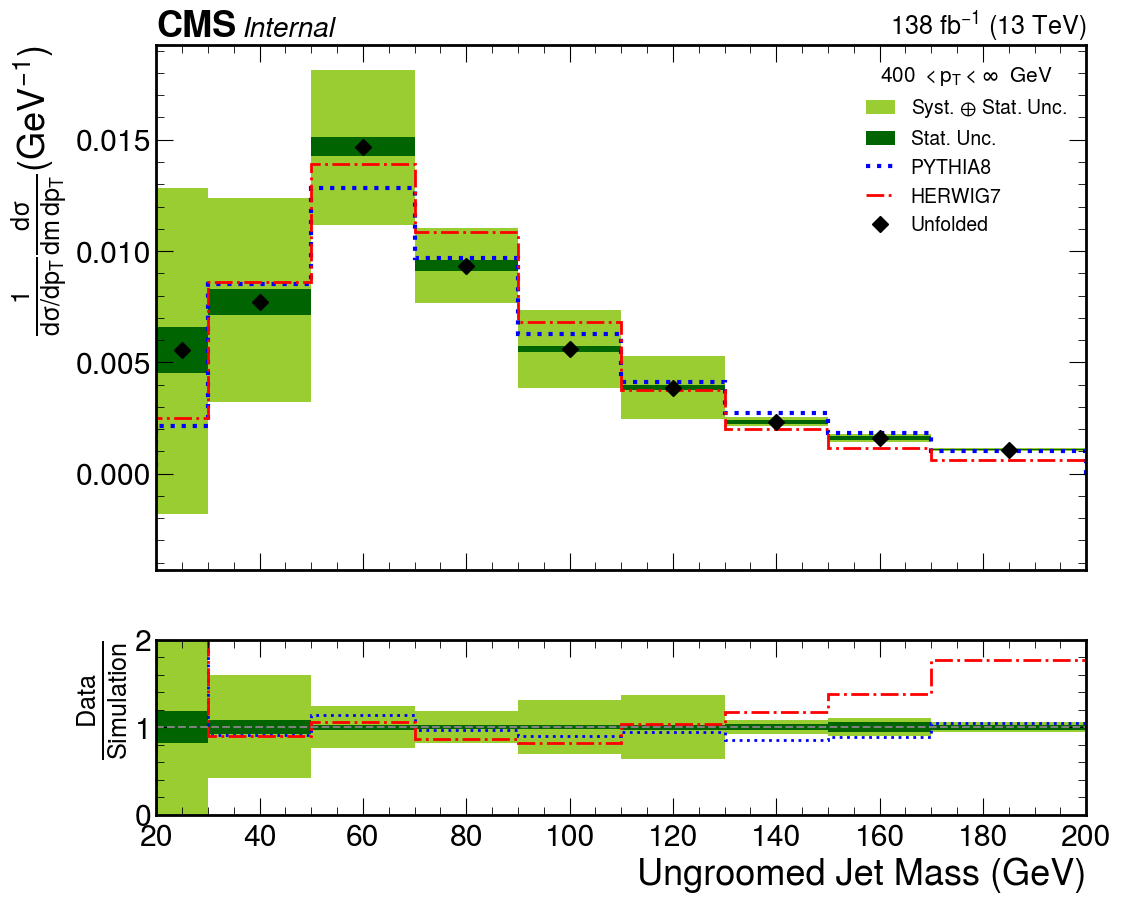

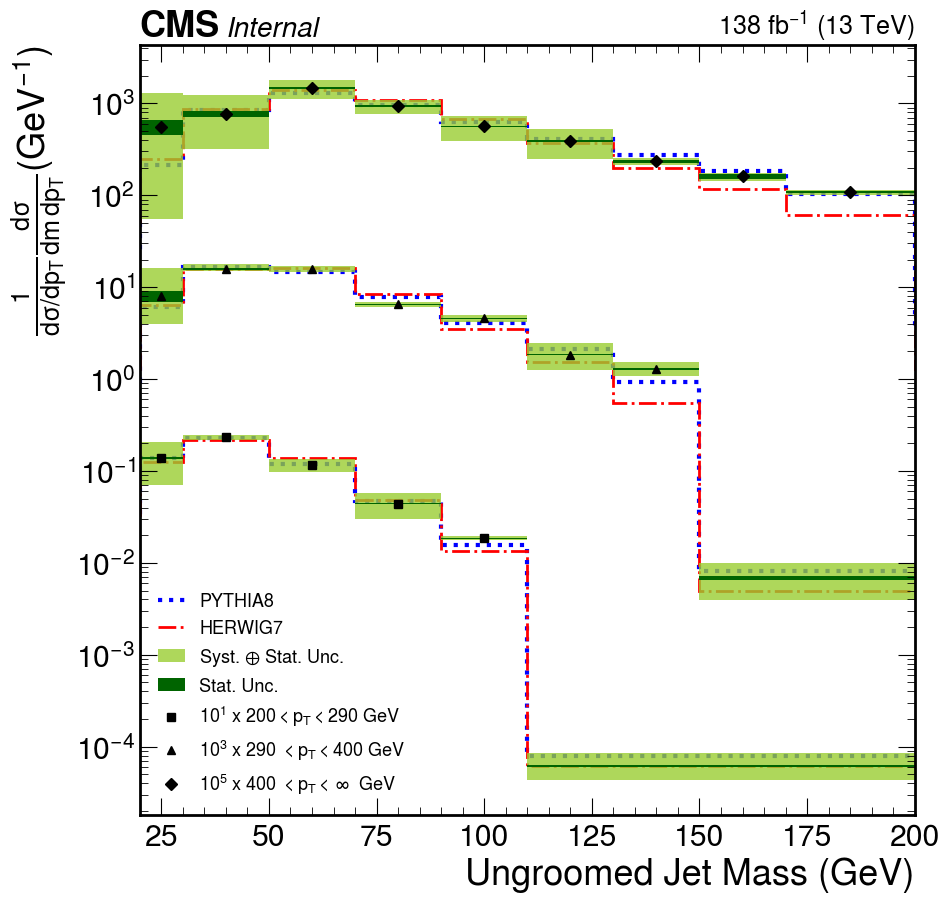

In [18]:
unfolder_ungroomed.plot_unfolded_fancy()

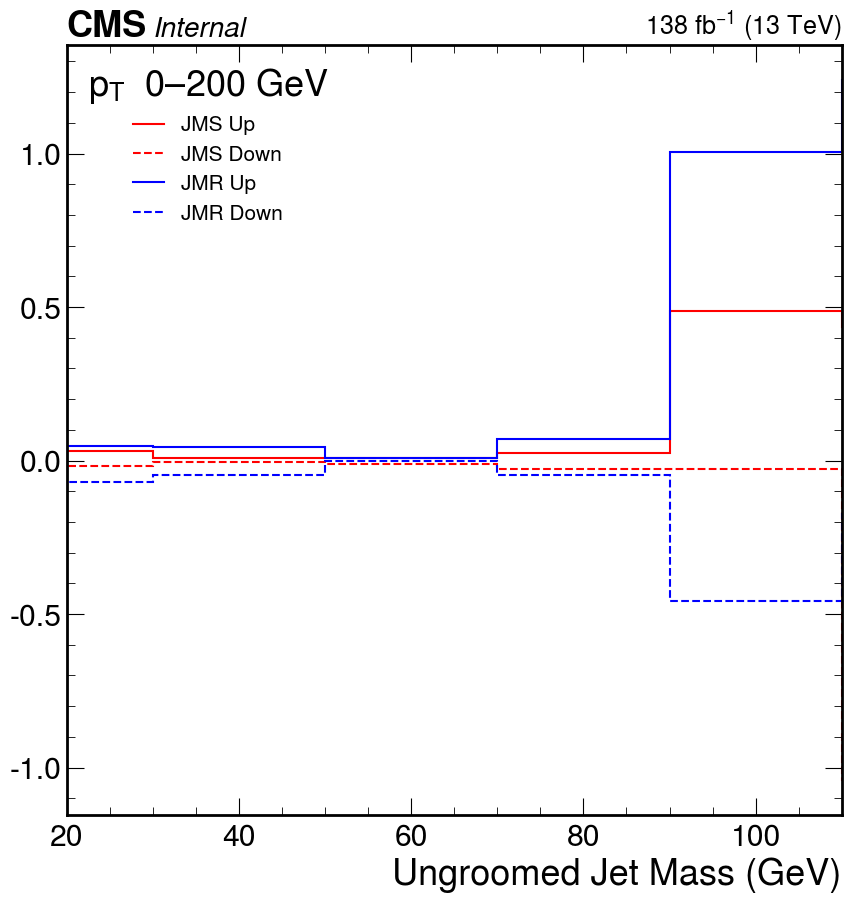

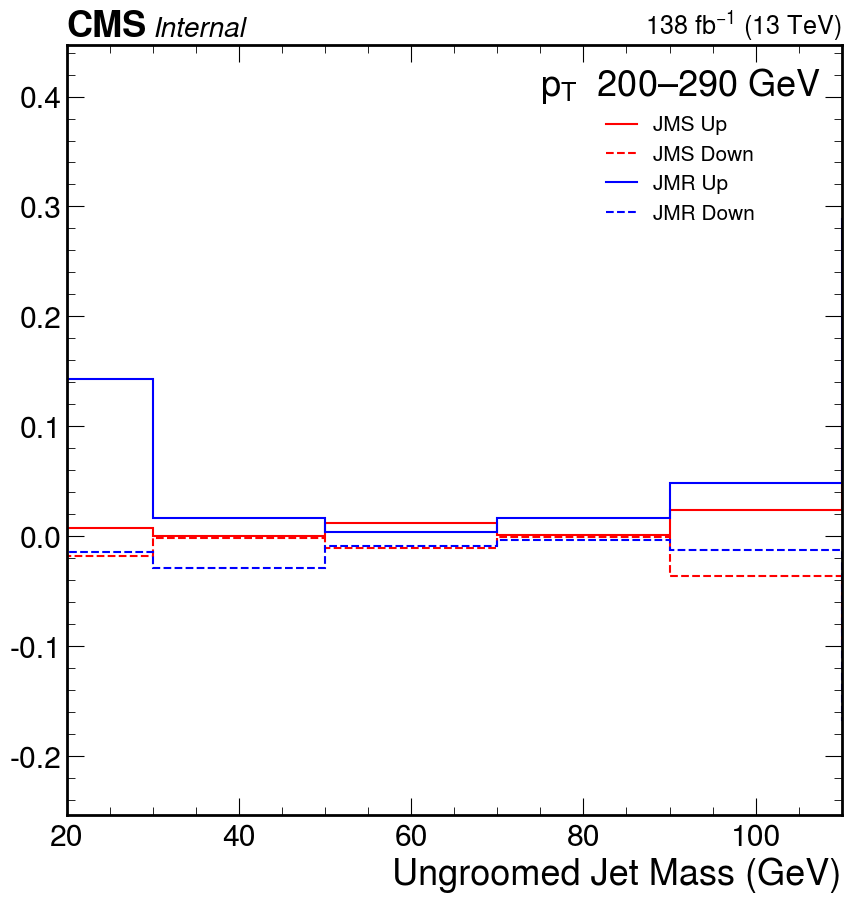

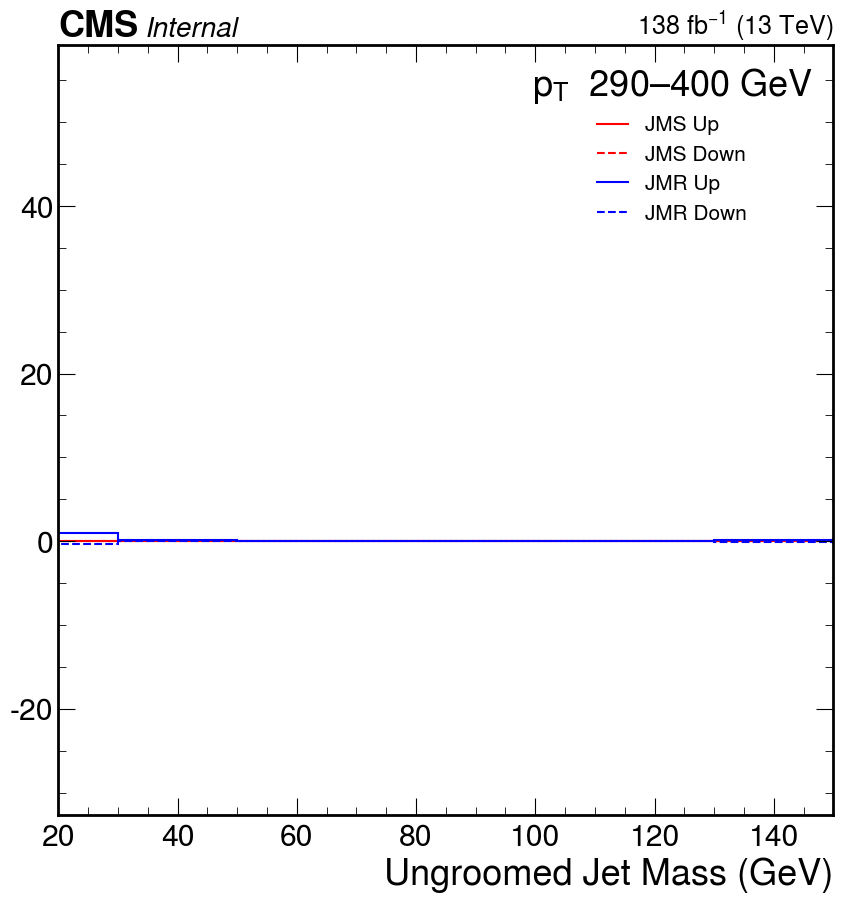

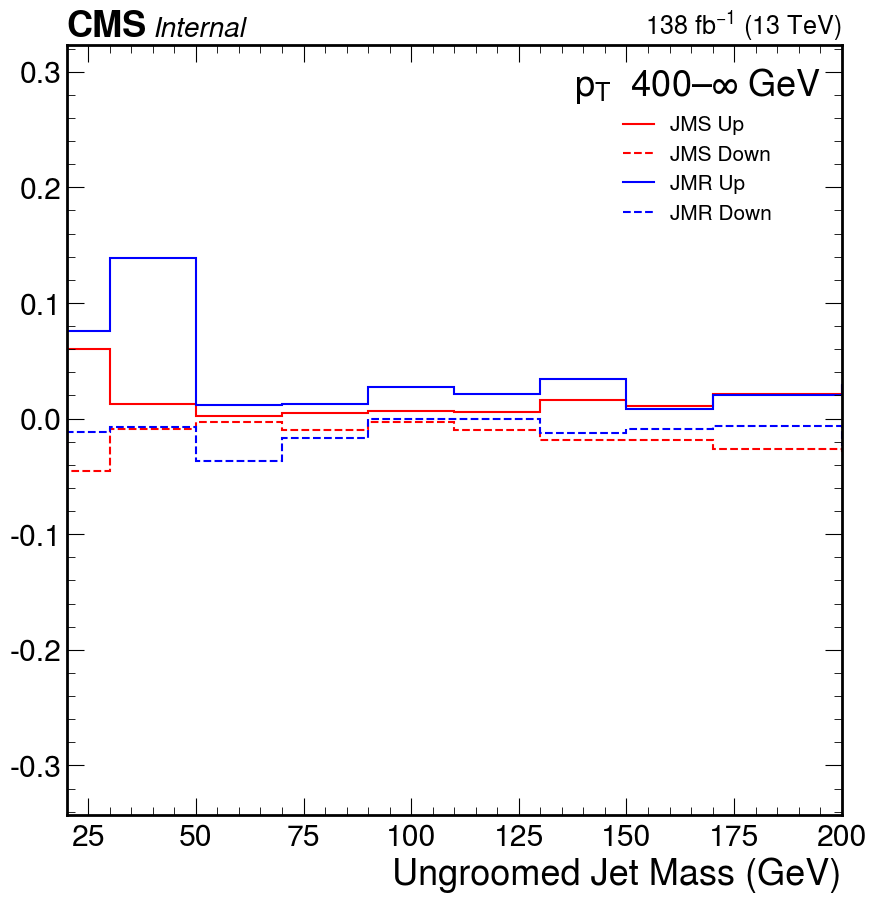

In [19]:
unfolder.plot_systematic_frac_indiv(["JMS", "JMR"])#(['isr', 'fsr'])

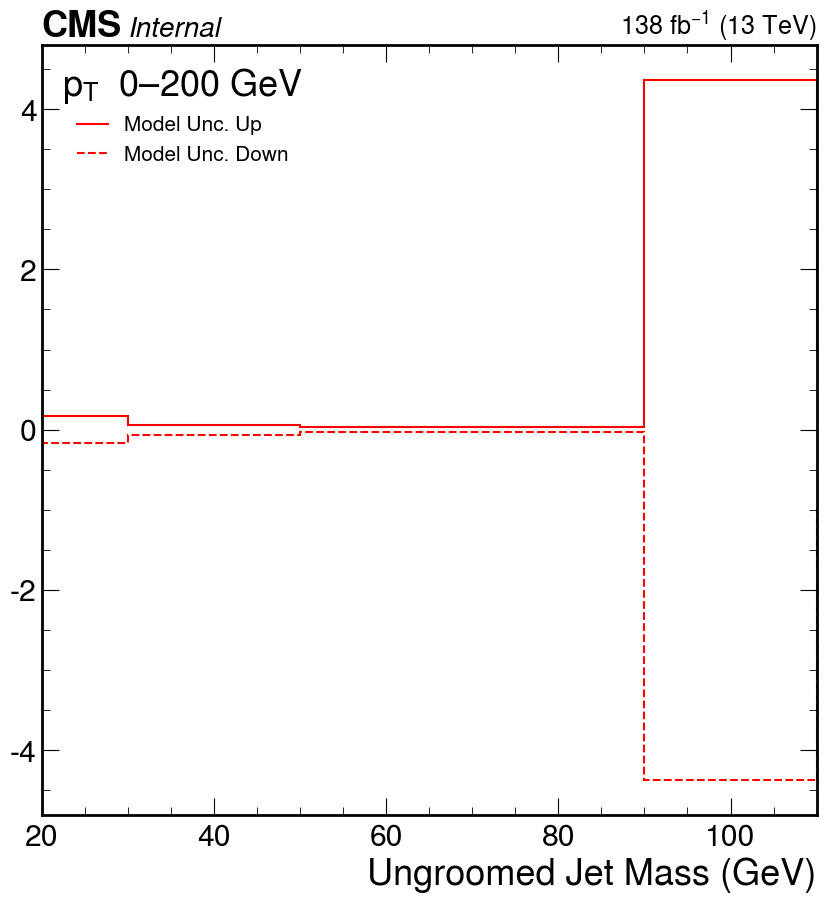

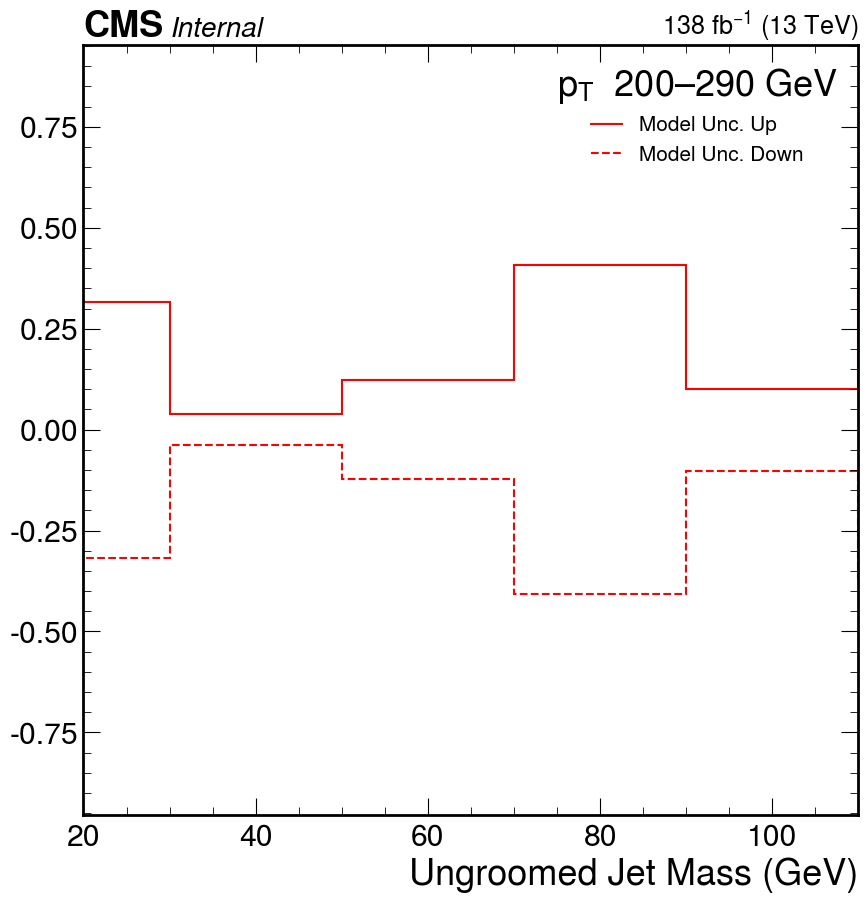

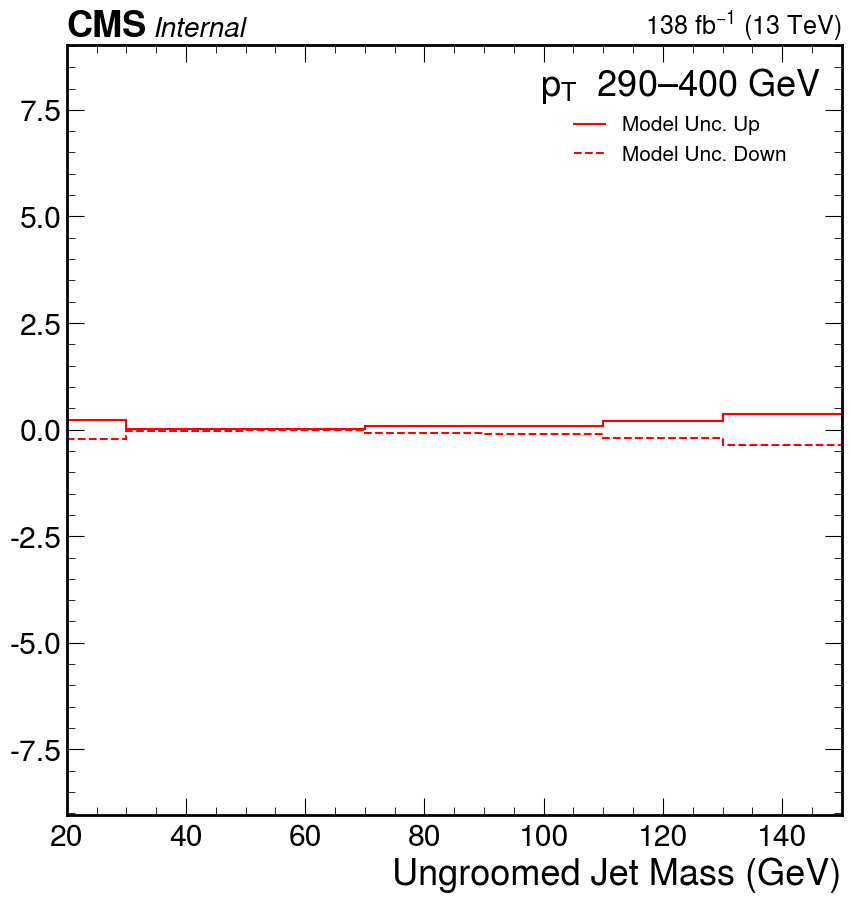

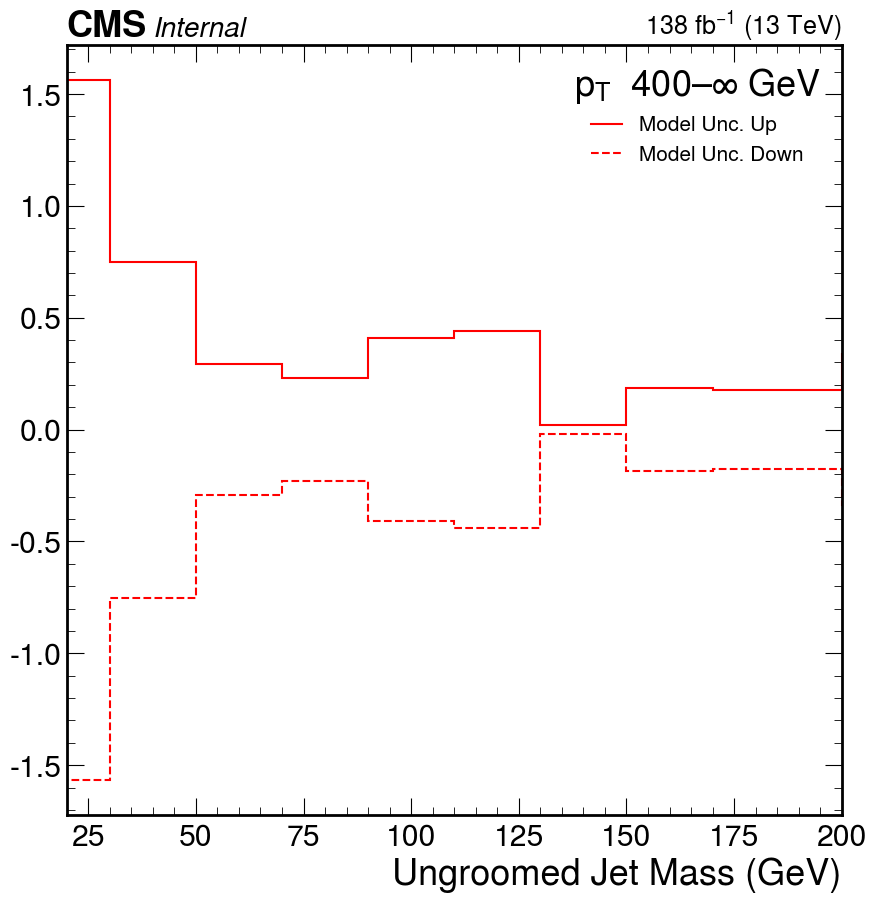

In [16]:
unfolder.plot_systematic_frac_indiv(["herwig"])#(['isr', 'fsr'])

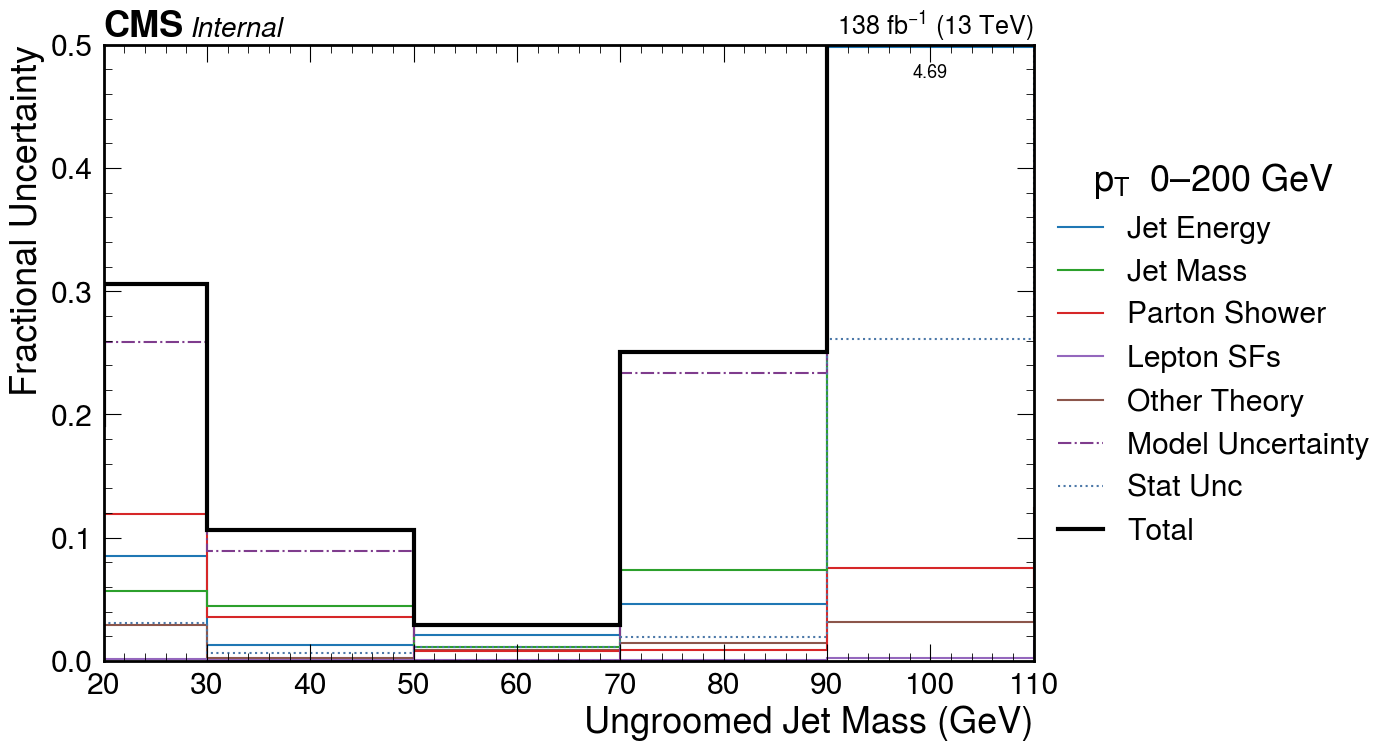

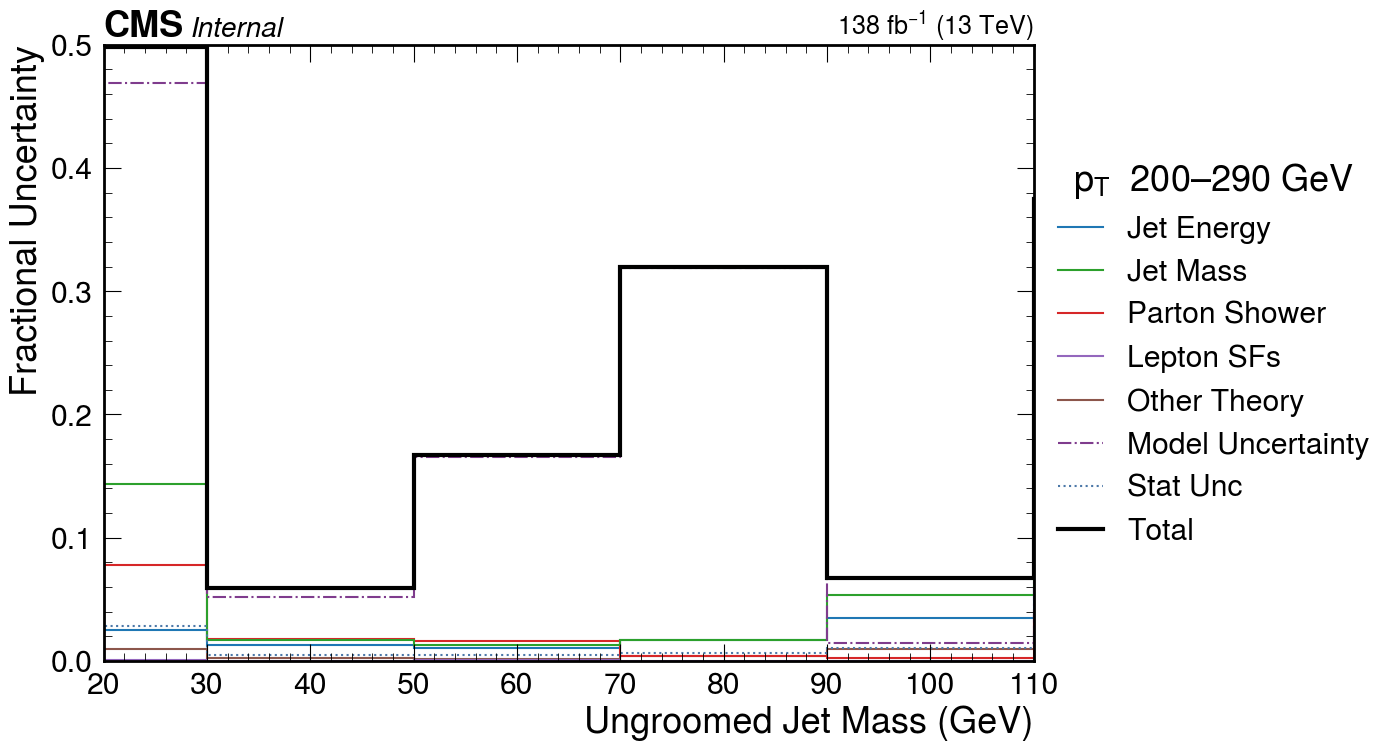

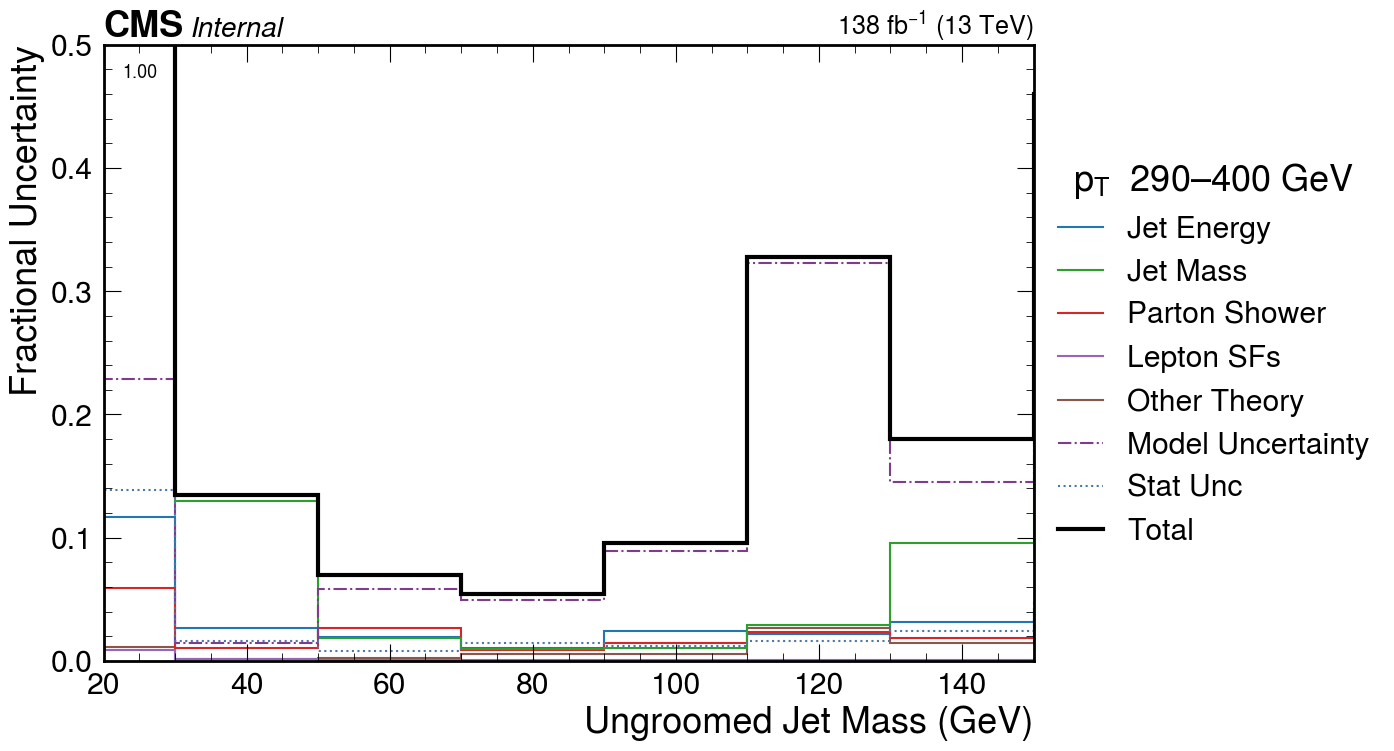

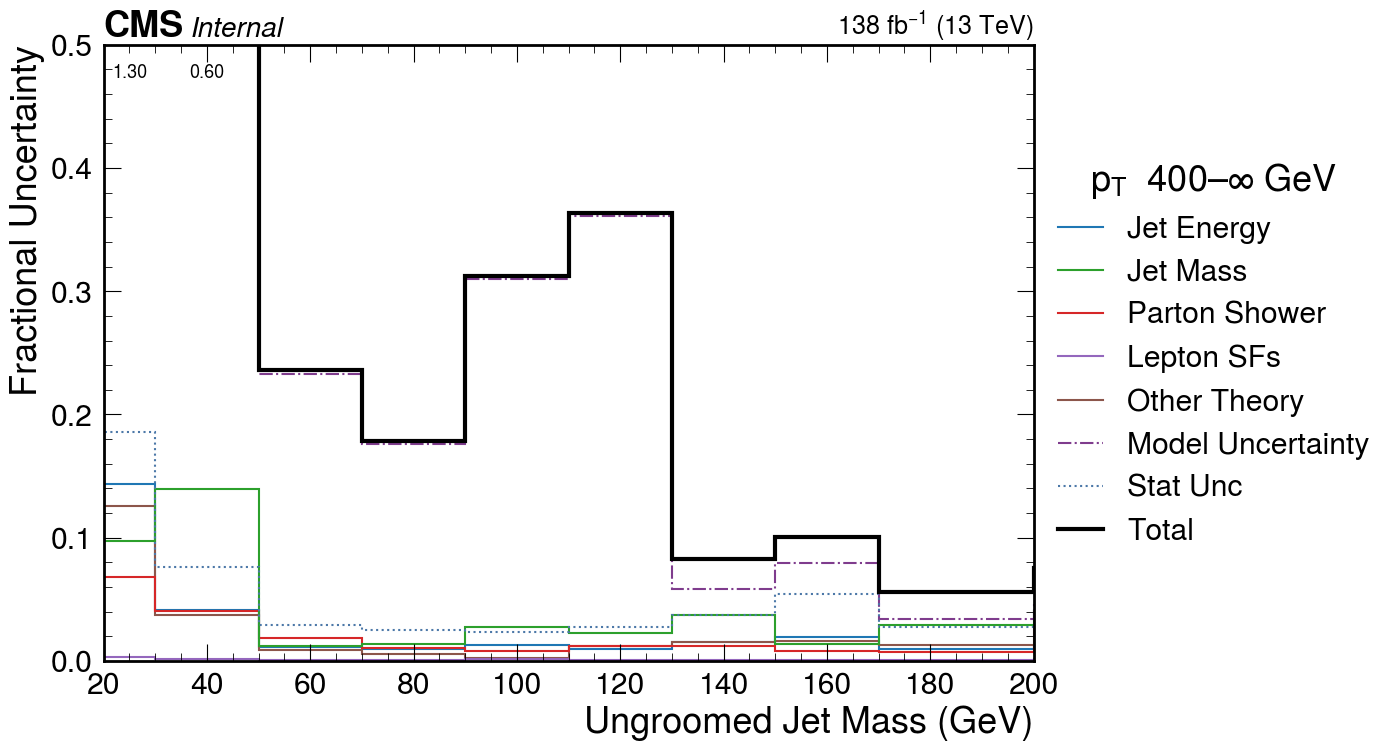

In [19]:
unfolder_ungroomed.plot_systematic_fraction_grouped(log = False)

In [ ]:
mosaic = unfolder.mosaic
# save in a npz file
np.savez("./outputs/unfolding_mosaic.npz", mosaic=mosaic)

mosaic_2d = unfolder.mosaic_2d
np.savez("./outputs/unfolding_mosaic_2d.npz", mosaic_2d=mosaic_2d)

In [ ]:
unfolder.plot_systematic_fraction()

In [ ]:
unfolder.plot_jk()

In [ ]:
#unfolder.plot_herwig_systematic()

In [ ]:
unfolder.plot_systematic_frac_indiv(["JES", "JER"], ylim = (-0.5, 0.5), show = True)

In [ ]:
unfolder.plot_systematic_frac_indiv(["JMS", "JMR"])
unfolder.plot_systematic_frac_indiv(["q2", "pdf", "pu","l1prefiring"])

In [ ]:
unfolder.plot_systematic_frac_indiv(["herwig"])

In [ ]:
unfolder.plot_systematic_frac_indiv(["ElectronSF", "MuonSF"])

In [ ]:
unfolder.plot_correlation()

In [ ]:
pt_list = ["", "200 - 290 GeV", "290 - 400 GeV", r"400 - $\infty$ GeV"]
edges = unfolder.bins.gen_mass_edges_by_pt[0][1:]
for i in range(1,4):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
    plt.sca(ax1)
    r1 = unfolder.normalized_systematics[i]['unfolded']['herwigUp'][1:]
    r2 = unfolder.normalized_results[i]['unfolded'][1:]
    #r3 = unfolder.normalized_systematics[i]['unfolded']['herwig0Up'][1:]

    plt.stairs(r1, edges, label = "Unfolded using Reweighted Pythia", linestyle = '--')
    #plt.stairs(r3, label = "Unfolded using Unweighted Herwig", linestyle = "--")
    plt.stairs(r2, edges, label = "Unfolded using Pythia", linestyle = '-', color = 'black')
    plt.legend(fontsize = 12, title = pt_list[i], title_fontsize = 15)

    plt.sca(ax2)
    plt.stairs(np.abs(r1-r2)/np.abs(r2), edges,  label = "Relative Difference (Rewighted Pythia)")
    #plt.stairs(np.abs(r3-r2)/np.abs(r2), label = "Relative Difference (Herwig)")
    #add horizontal line at y = 0.1, 0.25, 0.5
    plt.axhline(0.1, color = 'k', linestyle = '--', alpha = 0.5)
    plt.axhline(0.25, color = 'k', linestyle = '--',alpha = 0.5)
    #add text on the right side of the plot, on top of the horizontal lines, that says "10%", "25%" respectively
    plt.text(0.95, 0.1, "10%", transform = plt.gca().get_yaxis_transform(), ha = 'right', va = 'bottom', fontsize = 10, color = 'k', alpha = 0.5)
    plt.text(0.95, 0.25, "25%", transform = plt.gca().get_yaxis_transform(), ha = 'right', va = 'bottom', fontsize = 10, color = 'k', alpha = 0.5)
    plt.ylim(0, 1)
    plt.legend(fontsize = 15, )
    plt.xlabel("Groomed Jet Mass (GeV)" if groomed else "Ungroomed Jet Mass (GeV)")
    plt.show()
    


In [ ]:
unfolder.plot_unfolded()

In [ ]:
unfolder.plot_unfolded_fancy(log = False)

In [ ]:
for i in range(10):
    plt.stairs(np.abs(unfolder.mosaic_2d_jk_list[i][12:24]), unfolder.bins.reco_mass_edges_by_pt[2], label=int(i))
plt.legend()
plt.xlim(0, 215)
plt.xlabel("Ungroomed Jet Mass (GeV)")
plt.ylabel("# Events")
hep.cms.label("Internal", data=True, lumi=138)
plt.show()

for i in range(10):
    plt.stairs(np.abs(unfolder.y_unf_jk_input_list[i][6:12]), unfolder.bins.gen_mass_edges_by_pt[2], label=int(i))
plt.xlim(0, 215)
plt.xlabel("Ungroomed Jet Mass (GeV)")
plt.ylabel("# Events")
plt.legend()
hep.cms.label("Internal", data=True, lumi=138)
plt.show()


In [ ]:
import mplhep as hep
hep.style.use("CMS")
unfolder.plot_response_matrix(probability = True)

In [ ]:
unfolder.plot_correlation()

In [ ]:
plt.stairs(unfolder.misses_2d)

In [ ]:
unfolder.plot_folded()

In [ ]:
import numpy as np
np.min(unfolder.y_unf)

In [ ]:
unfolder.plot_bottom_line()

In [ ]:
# for i in range(1,4):
#     arr_unf = np.array(unfolder.normalized_results[i]['unfolded'])
#     arr_meas = np.array(unfolder.normalized_results[i]['measured'])
#     print(f"Pt bin {i}:")
#     print("Measured Data:", np.array2string(arr_meas, separator=', '))
#     print("Unfolded:", np.array2string(arr_unf, separator=', '))
    

In [ ]:
# herwig_matrix = unfolder.mosaic_dict['herwigUp']
# pythia_matrix = unfolder.mosaic_dict['nominal']
# #save them into a numpy readable file inside the ROOT_files folder
# import numpy as np
# np.save('ROOT_files/herwig_matrix_merged.npy', herwig_matrix)
# np.save('ROOT_files/pythia_matrix_merged.npy', pythia_matrix)

In [ ]:
#unfolder.normalized_systematics[2]

In [ ]:
unfolder.normalized_systematics[2]['unfolded'].keys()

In [ ]:
n_bins = len(unfolder.bins.reco_mass_bin_widths_by_pt[0])

In [ ]:

plt.stairs(unfolder.normalized_systematics[1]['unfolded']['JMRUp'], label = 'JMRUp')
#plt.stairs(unfolder.normalized_systematics[2]['unfolded']['JERUp'], label = 'JERUp')
#plt.stairs(unfolder.normalized_systematics[2]['unfolded']['JES_FlavorQCDUp_corr'], label = 'JESUp')

plt.stairs(unfolder.normalized_systematics[1]['unfolded']['JMRDown'], label = 'JMRDown')
#plt.stairs(unfolder.normalized_systematics[2]['unfolded']['JERDown'], label = 'JERDown')
#plt.stairs(unfolder.normalized_systematics[2]['unfolded']['JES_FlavorQCDDown_corr'], label = 'JESDown')

plt.stairs(unfolder.normalized_results[1]['unfolded'], label = 'nominal')
plt.xlabel('# Mass bin')
plt.title('Pt bin 2')
plt.legend()

In [ ]:
# plt.figure(figsize = (10,3))
# edges = unfolder.normalized_results[1]['mgen_edges'].copy()
# edges[-1] = 250
# hep.histplot(unfolder.normalized_results[1]['unfolded']/unfolder.normalized_results[1]['true'],edges, yerr =unfolder.normalized_results[1]['unfolded_err']/unfolder.normalized_results[1]['true'] , color = 'black', ls = 'dotted')
# plt.yalabel("Data/MC")
# plt.xlabel("Groomed Jet Mass (GeV)")
# plt.ylim(0, 2)
# plt.xlim(0,250)


In [ ]:
# i = 1
# plt.figure(figsize = (10,3))
# edges = unfolder.normalized_results[i]['mgen_edges'].copy()
# edges[-1] = 250
# hep.histplot((unfolder.normalized_results[i]['unfolded']-unfolder.normalized_herwig[i])/unfolder.normalized_herwig[i],edges, yerr =unfolder.normalized_results[i]['unfolded_err']/unfolder.normalized_results[i]['true'] , color = 'black', ls = 'dotted')
# #hep.histplot(np.ones(len(model)), edges, yerr = model/unfolder.normalized_herwig[1], histtype = 'errorbar')
# plt.ylabel("(Unfolded - True)/ \n True ")
# plt.xlabel("Groomed Jet Mass (GeV)")
# plt.title(title_list[i])
# #plt.ylim(0.7, 1.3)
# plt.xlim(10,250)

In [ ]:
filename = 'outputs/unfolding_data_groomed.pkl'

# Open the file in binary write mode ('wb').
# 'wb' is essential for pickle to work correctly.
with open(filename, 'wb') as file:
    # Use pickle.dump() to save the data to the file.
    pkl.dump(unfolder.normalized_results, file)


In [ ]:
# print(unfolder.normalized_results[0]['unfolded'])
# print(unfolder.normalized_systematics[0]['unfolded']['JERUp'])
# print(unfolder.normalized_systematics[0]['unfolded']['JERDown'])

# diff_up = unfolder.normalized_results[0]['unfolded'] - unfolder.normalized_systematics[0]['unfolded']['JERUp']
# print("Difference Up:", diff_up)

In [ ]:
# syst_list = unfolder.systematics

# for syst in syst_list:
#     if "Down" not in syst:
#         print("SHOULD BE UP")
#         print(syst)

In [ ]:
unfolder.plot_fakes_misses()

In [ ]:
unfolder.normalized_results[0].keys()

In [ ]:
unfolder.plot_systematic_fraction()

In [ ]:
unfolder.normalized_results[1]['syst_fraction_dict'].keys()

In [ ]:
unfolder.plot_systematic_frac_indiv(['JES','JER'])

In [ ]:
unfolder.plot_systematic_frac_indiv(['JMS', 'JMR'])

In [ ]:
unfolder.plot_systematic_frac_indiv(['q2','pdf', 'pu', 'prefiring'])

In [ ]:
unfolder.plot_systematic_frac_indiv(['ele'])

In [ ]:
unfolder.plot_correlation()

In [ ]:
# with open('latest_pkl/0508/all_lauren_bin_mc.pkl', "rb") as f:
#     output_pythia= pkl.load( f )
# plt.figure(figsize = (20, 20))
# for i in range(3):
#     plt.subplot(2, 2, i+1)
#     m2d_h = output_pythia['response_matrix_u'].project('ptreco', 'mreco', 'mgen')[i, :, :]
#     if i == 0:
#         m2d_h = rebin_hist(m2d_h, 'mgen', [0, 10, 20, 40 , 60, 80, 13000])
#         m2d_h = rebin_hist(m2d_h, 'mreco' , [0, 10, 20, 40 , 60, 80, 13000])
#     if i == 1:
#         m2d_h = rebin_hist(m2d_h, 'mgen', [0, 10, 20, 40 ,60, 80, 100, 13000])
#         m2d_h = rebin_hist(m2d_h, 'mreco' , [0, 10, 20, 40 ,60, 80, 100, 13000])
#     if i == 2:
#         m2d_h = rebin_hist(m2d_h, 'mgen', [0, 10, 20, 40, 60 , 80, 100, 150, 200,  13000])
#         m2d_h = rebin_hist(m2d_h, 'mreco' , [0, 10, 20, 40, 60 , 80, 100, 150, 200, 13000])
#     mass_edges = m2d_h.axes[1].edges
#     m2d = m2d_h.values()
#     plt.stairs(np.diag(m2d)/m2d.sum(axis=0), mass_edges, label = 'Purity', lw = 2)
#     plt.stairs(np.diag(m2d)/m2d.sum(axis=1), mass_edges, label = 'Stability', lw = 2)
#     plt.legend()
#     #draw a horizontal line at 0.5
#     plt.axhline(0.5, color='gray', ls='--')
#     plt.xlabel('Ungroomed Jet Mass (GeV)')
#     plt.ylabel('Purity/Stability')
#     hep.cms.label("Preliminary", data=False, rlabel = r"138 fb$^{-1}$")

#     xtick_labels = [str(int(tick)) for tick in mass_edges]  # Convert to string
#     xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
#     plt.tick_params(axis='x', which='minor', top=False, bottom=False)

#     plt.xticks(mass_edges, xtick_labels)
#     plt.xlim(19.8,250)
#     plt.ylim(0,1)
# plt.show()

In [ ]:
# import pickle as pkl
# import matplotlib.pyplot as plt
# import hist
# import mplhep as hep
hep.style.use("CMS")
with open('./inputs/massInputs/mass_pythia_all.pkl', "rb") as f:
    output_pythia = pkl.load(f)

from unfold.tools import binning
bins = binning.bin_edges(groomed=False)

plt.figure(figsize=(20, 20))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    m2d_h = output_pythia['response_matrix_u'].project('ptreco', 'mreco', 'mgen')[i, :, :]
    m2d_h = rebin_hist(m2d_h, 'mgen', bins.gen_mass_edges_by_pt[i])
    m2d_h = rebin_hist(m2d_h, 'mreco', bins.reco_mass_edges_by_pt[i])
    mass_edges = m2d_h.axes[1].edges
    m2d = m2d_h.values()
    plt.stairs(np.diag(m2d) / m2d.sum(axis=0), mass_edges, label='Purity', lw=2)
    plt.stairs(np.diag(m2d) / m2d.sum(axis=1), mass_edges, label='Stability', lw=2)
    plt.legend()
    plt.axhline(0.5, color='gray', ls='--')
    plt.xlabel('Ungroomed Jet Mass (GeV)')
    plt.ylabel('Purity/Stability')
    plt.xlim(0, 215)
    hep.cms.label("Internal", data=False, rlabel=r"138 fb$^{-1}$")


In [ ]:
with open('./inputs/massInputs/mass_pythia_all.pkl', "rb") as f:
    output_pythia = pkl.load(f)

from unfold.tools import binning
bins = binning.bin_edges(groomed=True)

plt.figure(figsize=(20, 20))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    m2d_h = output_pythia['response_matrix_g'].project('ptreco', 'mreco', 'mgen')[i, :, :]
    m2d_h = rebin_hist(m2d_h, 'mgen', bins.gen_mass_edges_by_pt[i])
    m2d_h = rebin_hist(m2d_h, 'mreco', bins.reco_mass_edges_by_pt[i])
    mass_edges = m2d_h.axes[1].edges
    m2d = m2d_h.values()
    plt.stairs(np.diag(m2d) / m2d.sum(axis=0), mass_edges, label='Purity', lw=2)
    plt.stairs(np.diag(m2d) / m2d.sum(axis=1), mass_edges, label='Stability', lw=2)
    plt.legend()
    plt.axhline(0.5, color='gray', ls='--')
    plt.xlabel('Groomed Jet Mass (GeV)')
    plt.ylabel('Purity/Stability')
    plt.xlim(0, 200)
    hep.cms.label("Internal", data=False, rlabel=r"138 fb$^{-1}$")


In [ ]:
title_list = ["",r"200 $<$ $p_T$ $<$ 290 GeV", r"290 $<$ $p_T$ $<$ 400 GeV", r"400 $<$ $p_T$ $< \, \infty$  GeV"]
rlabel = r"138 fb$^{-1}$ (13 TeV)"
with open('./inputs/massInputs/mass_pythia_all.pkl', "rb") as f:
    output_pythia= pkl.load( f )

with open('./inputs/massInputs/mass_data_all.pkl', "rb") as f:
    output_data= pkl.load( f )

with open('./inputs/massInputs/mass_herwig_all.pkl', "rb") as f:
    output_herwig= pkl.load( f )

groomed = False
from unfold.tools import binning
bins = binning.bin_edges(groomed=groomed)

for ipt in range(4):
    mreco_edge = bins.reco_mass_edges_by_pt[ipt]
    mreco_edge_new = mreco_edge.copy()


    
    mreco_width = np.diff(mreco_edge)
    

    fig, (ax_main, ax_ratio) = plt.subplots(2, 1, sharex=True,
                                              
                                              gridspec_kw={'height_ratios': [3, 1]})
    resp_matrix_4d = output_pythia['response_matrix_u'] if not groomed else output_pythia['response_matrix_g']
    resp_matrix_4d_herwig = output_herwig['response_matrix_u'] if not groomed else output_herwig['response_matrix_g']
    input_data = output_data['ptjet_mjet_u_reco'] if not groomed else output_data['ptjet_mjet_g_reco']

    # use rebin_hist to rebin the histograms to the mreco_edge 

    resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mreco', mreco_edge)
    resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mreco', mreco_edge)
    input_data = rebin_hist(input_data, 'mreco', mreco_edge)
    
    mc_values = resp_matrix_4d.project('systematic','ptreco', 'mreco')['nominal',ipt, :].values()
    mc_values_norm = mc_values/mreco_width/mc_values.sum()
    mc_stat =  resp_matrix_4d.project('systematic','ptreco', 'mreco')['nominal',ipt, :].variances()**0.5
    mc_stat_norm = mc_stat/mreco_width/mc_values.sum()

    mc2_values = resp_matrix_4d_herwig.project('systematic','ptreco', 'mreco')['nominal',ipt, :].values()
    mc2_values_norm = mc2_values/mreco_width/mc2_values.sum()
    mc2_stat =  resp_matrix_4d_herwig.project('systematic','ptreco', 'mreco')['nominal',ipt, :].variances()**0.5
    mc2_stat_norm = mc2_stat/mreco_width/mc2_values.sum()

    
    data_values = input_data.project('ptreco', 'mreco')[ipt, :].values()
    data_values_norm = data_values/mreco_width/data_values.sum()
    data_stat = input_data.project('ptreco', 'mreco')[ipt, :].variances()**0.5
    data_stat_norm = data_stat/mreco_width/data_values.sum()


    ratio = np.divide(np.abs(mc_values_norm), np.abs(data_values_norm), out=np.ones_like(mc_values), where=data_values != 0)
    ratio2 = np.divide(np.abs(mc2_values_norm), np.abs(data_values_norm), out=np.ones_like(mc_values), where=data_values != 0)

    
    # hep.histplot(mc_values_norm, mreco_edge_new, yerr = mc_stat_norm, color = 'r',label = "PYTHIA", ax = ax_main)
    # hep.histplot(mc2_values_norm, mreco_edge_new, yerr = mc_stat_norm, color = 'b', label = "herwig7", ax = ax_main)
    # hep.histplot(data_values_norm, mreco_edge_new, yerr = data_stat_norm, color = 'k', label = "Data", ax = ax_main)
    # #ax_main.set_yscale('log')

    # print(data_values_norm)
    
    
    # plt.ylabel("#Events/GeV")
    # ax_main.legend(title = title_list[ipt])
    # xtick_labels = [str(int(tick)) for tick in mreco_edge_new]  # Convert to string
    # xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    # plt.tick_params(axis='x', which='minor', top=False, bottom=False)
    # hep.cms.label("Preliminary", rlabel = rlabel, ax = ax_main)

    # #ax_main.set_yscale('log')



    # ax_ratio.stairs(ratio, mreco_edge_new, label="PYTHIA", color='r', lw= 2)
    # ax_ratio.stairs(ratio2, mreco_edge_new, label="PYTHIA", color='b', lw= 2)
    # ax_ratio.axhline(1, color='gray', linestyle='--')  # Reference line at 1
    mreco_edge_new = np.array(mreco_edge_new)
    # --- Main plots ---
    hep.histplot(mc_values_norm, mreco_edge_new, yerr=mc_stat_norm,
                 color='r', label="PYTHIA", ax=ax_main)
    hep.histplot(mc2_values_norm, mreco_edge_new, yerr=mc2_stat_norm,
                 color='b', label="Herwig7", ax=ax_main)
    hep.histplot(data_values_norm, mreco_edge_new, yerr=data_stat_norm,
                 color='k', label="Data", ax=ax_main)
    
    plt.ylabel("#Events/GeV")
    ax_main.legend(title=title_list[ipt])
    xtick_labels = [str(int(tick)) for tick in mreco_edge_new]
    xtick_labels[-1] = r"$\infty$"
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)
    hep.cms.label("Preliminary", rlabel=rlabel, ax=ax_main)
    
    # --- Ratio calculation ---
    ratio1 = data_values_norm / mc_values_norm
    ratio2 = data_values_norm / mc2_values_norm
    
    # Error propagation
    ratio1_err = ratio1 * np.sqrt(
        (data_stat_norm / data_values_norm)**2 +
        (mc_stat_norm / mc_values_norm)**2
    )
    ratio2_err = ratio2 * np.sqrt(
        (data_stat_norm / data_values_norm)**2 +
        (mc2_stat_norm / mc2_values_norm)**2
    )
    
    # --- Ratio plots ---
    ax_ratio.stairs(ratio1, mreco_edge_new, label="PYTHIA", color='r', lw=2)
    ax_ratio.errorbar(
        0.5 * np.array(mreco_edge_new[1:] + mreco_edge_new[:-1]),  # bin centers
        ratio1,
        yerr=ratio1_err,
        fmt='.',
        color='r',

    )
    
    ax_ratio.stairs(ratio2, mreco_edge_new, label="Herwig7", color='b', lw=2)
    ax_ratio.errorbar(
        0.5 * np.array(mreco_edge_new[1:] + mreco_edge_new[:-1]),
        ratio2,
        yerr=ratio2_err,
        fmt='.',
        color='b'
    )
    
    ax_ratio.axhline(1, color='gray', linestyle='--')  # Reference line

    if not groomed:
        ax_ratio.set_xlabel("Ungroomed Jet Mass (GeV)")
        ax_ratio.set_xlim(0, 215)
    else:
        ax_ratio.set_xlabel("Groomed Jet Mass (GeV)")
        ax_ratio.set_xlim(0, 200)
    
    ax_ratio.set_ylabel("Theory/Data")
    ax_ratio.set_ylim(0.5, 1.5)
    
    
    plt.tight_layout()


    # if groomed:
    #     plt.savefig(f'plots/unfold/input_groomed_{ipt}.pdf')
    # else:
    #     plt.savefig(f'plots/unfold/input_ungroomed_{ipt}.pdf')
    # #plt.xticks(mreco_edge_new, xtick_labels)
    plt.show()

In [ ]:
mreco_edge_new = np.array(mreco_edge_new)
0.5 * (mreco_edge_new[1:] + mreco_edge_new[:-1])

In [ ]:
fakes_herwig = output_herwig['fakes_u'].project('ptreco', 'mreco')
ptjet_mjet_herwig = output_herwig['ptjet_mjet_u_reco'].project('ptreco', 'mreco')

fakes = output_pythia['fakes_u'].project('ptreco', 'mreco')
ptjet_mjet = output_pythia['ptjet_mjet_u_reco'].project('ptreco', 'mreco')


# misses / gen analog
misses_herwig = output_herwig['misses_u'].project('ptgen', 'mgen')
ptjet_mjet_herwig_gen = output_herwig['response_matrix_u'][{'systematic': 'herwig'}].project('ptgen', 'mgen')

misses = output_pythia['misses_u'].project('ptgen', 'mgen')
ptjet_mjet_gen = output_pythia['response_matrix_u'][{'systematic': 'nominal'}].project('ptgen', 'mgen')


for i in range(len(fakes.values())):
    
    mreco_edge = bins.reco_mass_edges_by_pt[ipt]
    mreco_edge_new = mreco_edge.copy()
    if ipt == 0:
        mreco_edge_new[-1] = 250
    if ipt == 1:
        mreco_edge_new[-1] = 250
    if ipt == 2:
        mreco_edge_new[-1] = 1000

    mgen_edge = bins.gen_mass_edges_by_pt[ipt]
    mgen_edge_new = mgen_edge.copy()
    if ipt == 0:
        mgen_edge_new[-1] = 250
    if ipt == 1:
        mgen_edge_new[-1] = 250
    if ipt == 2:
        mgen_edge_new[-1] = 1000


    mreco_width = np.diff(mreco_edge)

    fakes = rebin_hist(fakes, 'mreco', mreco_edge)
    fakes_herwig = rebin_hist(fakes_herwig, 'mreco', mreco_edge)
    ptjet_mjet = rebin_hist(ptjet_mjet, 'mreco', mreco_edge)
    ptjet_mjet_herwig = rebin_hist(ptjet_mjet_herwig, 'mreco', mreco_edge)

    misses = rebin_hist(misses, 'mgen', mgen_edge)
    misses_herwig = rebin_hist(misses_herwig, 'mgen', mgen_edge)
    ptjet_mjet_herwig_gen = rebin_hist(ptjet_mjet_herwig_gen, 'mgen', mgen_edge)
    ptjet_mjet_gen = rebin_hist(ptjet_mjet_gen, 'mgen', mgen_edge)

    true_miss_values = misses[i, :].values() - ptjet_mjet_gen[0, :].values()
    true_miss_values_herwig = misses_herwig[i, :].values() - ptjet_mjet_herwig_gen[0, :].values()

    miss_rate = misses[i, :].values()/(ptjet_mjet_gen[i, :].values()+misses[i, :].values())
    miss_rate_herwig = misses_herwig[i, :].values()/(ptjet_mjet_herwig_gen[i, :].values()+misses_herwig[i, :].values())

    # miss_rate = true_miss_values/(ptjet_mjet_gen[i, :].values()+true_miss_values)
    # miss_rate_herwig = true_miss_values_herwig/(ptjet_mjet_herwig_gen[i, :].values()+true_miss_values_herwig)

    fake_fraction = fakes[i, :].values()/ptjet_mjet[i, :].values()
    fake_fraction_herwig = fakes_herwig[i, :].values()/ptjet_mjet_herwig[i, :].values()


    #hep.histplot(1 - fake_fraction_herwig, mreco_edge, label = '1 - Fakes Herwig', color = 'red', ls = '--')
    hep.histplot(1 - fake_fraction, mreco_edge, label = '1 - Fakes Pythia', color = 'blue', ls = '-')
    #hep.histplot(miss_rate_herwig, mgen_edge, label = 'Miss Rate Herwig', color = 'red', ls = '-')
    hep.histplot(miss_rate, mgen_edge, label = 'Miss Rate Pythia', color = 'red', ls = '-')
    plt.legend(title = title_list[i])
    plt.xlabel("Groomed Jet Mass (GeV)" if groomed else "Ungroomed Jet Mass (GeV)")
    hep.cms.label("Preliminary", rlabel = r"138 $fb^{-1} (13 TeV)$")
    plt.ylabel("Fraction")
    plt.xlim(0, 300)
    plt.show()

In [ ]:
fakes_herwig = output_herwig['fakes_g'].project('ptreco', 'mreco')
ptjet_mjet_herwig = output_herwig['ptjet_mjet_g_reco'].project('ptreco', 'mreco')

fakes = output_pythia['fakes_g'].project('ptreco', 'mreco')
ptjet_mjet = output_pythia['ptjet_mjet_g_reco'].project('ptreco', 'mreco')


# misses / gen analog
misses_herwig = output_herwig['misses_g'].project('ptgen', 'mgen')
ptjet_mjet_herwig_gen = output_herwig['response_matrix_g'][{'systematic': 'herwig'}].project('ptgen', 'mgen')

misses = output_pythia['misses_g'].project('ptgen', 'mgen')
ptjet_mjet_gen = output_pythia['response_matrix_g'][{'systematic': 'nominal'}].project('ptgen', 'mgen')


for i in range(len(fakes.values())):
    
    mreco_edge = bins.reco_mass_edges_by_pt[ipt]
    mreco_edge_new = mreco_edge.copy()
    if ipt == 0:
        mreco_edge_new[-1] = 250
    if ipt == 1:
        mreco_edge_new[-1] = 250
    if ipt == 2:
        mreco_edge_new[-1] = 1000

    mgen_edge = bins.gen_mass_edges_by_pt[ipt]
    mgen_edge_new = mgen_edge.copy()
    if ipt == 0:
        mgen_edge_new[-1] = 250
    if ipt == 1:
        mgen_edge_new[-1] = 250
    if ipt == 2:
        mgen_edge_new[-1] = 1000


    mreco_width = np.diff(mreco_edge)

    fakes = rebin_hist(fakes, 'mreco', mreco_edge)
    fakes_herwig = rebin_hist(fakes_herwig, 'mreco', mreco_edge)
    ptjet_mjet = rebin_hist(ptjet_mjet, 'mreco', mreco_edge)
    ptjet_mjet_herwig = rebin_hist(ptjet_mjet_herwig, 'mreco', mreco_edge)

    misses = rebin_hist(misses, 'mgen', mgen_edge)
    misses_herwig = rebin_hist(misses_herwig, 'mgen', mgen_edge)
    ptjet_mjet_herwig_gen = rebin_hist(ptjet_mjet_herwig_gen, 'mgen', mgen_edge)
    ptjet_mjet_gen = rebin_hist(ptjet_mjet_gen, 'mgen', mgen_edge)

    true_miss_values = misses[i, :].values() - ptjet_mjet_gen[0, :].values()
    true_miss_values_herwig = misses_herwig[i, :].values() - ptjet_mjet_herwig_gen[0, :].values()

    miss_rate = misses[i, :].values()/(ptjet_mjet_gen[i, :].values()+misses[i, :].values())
    miss_rate_herwig = misses_herwig[i, :].values()/(ptjet_mjet_herwig_gen[i, :].values()+misses_herwig[i, :].values())

    # miss_rate = true_miss_values/(ptjet_mjet_gen[i, :].values()+true_miss_values)
    # miss_rate_herwig = true_miss_values_herwig/(ptjet_mjet_herwig_gen[i, :].values()+true_miss_values_herwig)

    fake_fraction = fakes[i, :].values()/ptjet_mjet[i, :].values()
    fake_fraction_herwig = fakes_herwig[i, :].values()/ptjet_mjet_herwig[i, :].values()


    #hep.histplot(1 - fake_fraction_herwig, mreco_edge, label = '1 - Fakes Herwig', color = 'red', ls = '--')
    hep.histplot(1 - fake_fraction, mreco_edge, label = '1 - Fakes Pythia', color = 'blue', ls = '-')
    #hep.histplot(miss_rate_herwig, mgen_edge, label = 'Miss Rate Herwig', color = 'red', ls = '-')
    hep.histplot(miss_rate, mgen_edge, label = 'Miss Rate Pythia', color = 'red', ls = '-')
    plt.legend(title = title_list[i])
    plt.xlabel("Groomed Jet Mass (GeV)")
    hep.cms.label("Preliminary", rlabel = r"138 $fb^{-1} (13 TeV)$")
    plt.ylabel("Fraction")
    plt.xlim(0, 300)
    plt.show()
